# Adicionar colunas faltantes ao dataset consolidado

Este notebook complementa `data/processed/dados_saneamento_snis_sinisa.csv` com novas variáveis a partir das bases SNIS e SINISA.

**Regras gerais**

- Trabalhamos apenas com municípios do Rio de Janeiro (UF = `RJ`).
- A junção é sempre feita pela dupla **(`ano`, `id_municipio`)** (código IBGE de 7 dígitos).
- Mantemos o cabeçalho de 3 linhas do CSV (nome amigável, unidade, identificador técnico).

**Variáveis adicionadas**

| Tema | Variável | Fonte 1995–2022 | Fonte 2023–2024 |
|------|----------|-----------------|-----------------|
| População | `populacao_rural` | derivado (`pop_total − pop_urbana`) | SINISA Resíduos (DFE0003) |
| Água | `indice_perda_distribuicao_agua` | SNIS | SINISA Água |
| Água | `indice_macromedicao` | SNIS | SINISA Água |
| Água | `indice_hidrometracao` | SNIS | SINISA Água |
| Investimento | `investimento_total` (prestador + município + estado) | SNIS | — |
| Investimento | `investimento_per_capita` = `investimento_total / populacao_total_residente` | derivado | derivado |
| Resíduos – domicílios e território | `domicilios_totais`, `domicilios_urbanos`, `domicilios_rurais`, `area_municipio_km2` | — | SINISA Resíduos (OGM4006/4004/4005/0005) |
| Resíduos – cobertura | `cobertura_residuos_solidos` (IRS0001), `cobertura_residuos_urbana` (IRS0002), `cobertura_residuos_rural` (IRS0003), `cobertura_residuos_urbana_direta` (IRS0004), `cobertura_coleta_seletiva_total` (IRS0005), `cobertura_coleta_seletiva_urbana` (IRS0006) | — | SINISA Resíduos |
| Resíduos – operacionais | `incidencia_transbordo_rsu` (IRS1001), `capacidade_veiculos_coleta_rsu` (IRS1002), `pontos_entrega_voluntaria_pev` (IRS1003), `massa_per_capita_rsu_coletado` (IRS1004), `massa_per_capita_rsd_coletado` (IRS1005), `massa_per_capita_limpeza_urbana` (IRS1006), `massa_per_capita_coleta_seletiva` (IRS1007), `massa_per_capita_recuperados` (IRS1008) | — | SINISA Resíduos |
| Resíduos – qualidade | `desempenho_coleta_seletiva` (IRS3001), `disposicao_final_inadequada_rsu` (IRS3002), `recuperacao_reciclaveis_secos_gravimetrica` (IRS3004), `recuperacao_reciclaveis_organicos_gravimetrica` (IRS3005), `recuperacao_total_reciclaveis` (IRS3010), `recuperacao_reciclaveis_secos` (IRS3011, só 2024), `recuperacao_reciclaveis_organicos` (IRS3012, só 2024) | — | SINISA Resíduos |

In [56]:
from pathlib import Path
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

CSV_PATH = PROJECT_ROOT / "data" / "processed" / "dados_saneamento_snis_sinisa.csv"
XLSX_PATH = PROJECT_ROOT / "data" / "processed" / "dados_saneamento_snis_sinisa.xlsx"

SNIS_CSV = PROJECT_ROOT / "data" / "raw" / "sinisa" / "snis" / "snis_rj.csv"

SINISA_AGUA_2023 = PROJECT_ROOT / "data" / "raw" / "sinisa" / "agua" / "2023" / "SINISA_AGUA_Indicadores_Base Municipal_2023_V2.xlsx"
SINISA_AGUA_2024 = PROJECT_ROOT / "data" / "raw" / "sinisa" / "agua" / "2024" / "SINISA_AGUA_Indicadores_Base Municipal_2024.xlsx"

SINISA_RESIDUOS_2023 = PROJECT_ROOT / "data" / "raw" / "sinisa" / "residuos" / "SINISA_RESIDUOS_Indicadores_2023.xlsx"
SINISA_RESIDUOS_2024 = PROJECT_ROOT / "data" / "raw" / "sinisa" / "residuos" / "SINISA_RESIDUOS_Indicadores_2024.xlsx"

UF_ALVO = "RJ"

for p in [CSV_PATH, SNIS_CSV, SINISA_AGUA_2023, SINISA_AGUA_2024, SINISA_RESIDUOS_2023, SINISA_RESIDUOS_2024]:
    assert p.exists(), f"Arquivo não encontrado: {p}"

print("Todos os arquivos de origem estão acessíveis.")

Todos os arquivos de origem estão acessíveis.


## 1. Carregar o CSV consolidado

O CSV tem **3 linhas de cabeçalho**:

- linha 0 → nome amigável (português)
- linha 1 → unidade
- linha 2 → identificador técnico (snake_case)

Vamos guardar esses cabeçalhos para reescrevê-los no final, e carregar os dados convertendo números no formato brasileiro (`1.234,56`).

In [57]:
def parse_br_number(val):
    """Converte número em formato brasileiro (1.000,50) para float."""
    if pd.isna(val):
        return np.nan
    s = str(val).strip().strip('"')
    if s == "" or s == " ":
        return np.nan
    s = s.replace(".", "").replace(",", ".")
    try:
        return float(s)
    except ValueError:
        return np.nan


header_raw = pd.read_csv(
    CSV_PATH, nrows=3, header=None, dtype=str, encoding="utf-8", keep_default_na=False
)
header_nomes_amigaveis = header_raw.iloc[0].tolist()
header_unidades = header_raw.iloc[1].tolist()
header_tecnicos = header_raw.iloc[2].tolist()

df = pd.read_csv(CSV_PATH, skiprows=[1, 2], dtype=str, encoding="utf-8")
df.columns = header_tecnicos

numeric_cols = [c for c in df.columns if c not in ("ano", "id_municipio", "nome_municipio", "sigla_uf")]
for col in numeric_cols:
    df[col] = df[col].apply(parse_br_number)

df["ano"] = df["ano"].astype(int)
df["id_municipio"] = df["id_municipio"].astype(str).str.strip()

df = df[df["sigla_uf"] == UF_ALVO].copy()
df = df.sort_values(["ano", "id_municipio"]).reset_index(drop=True)

print(f"Linhas: {len(df):,}")
print(f"Anos:   {df['ano'].min()}–{df['ano'].max()}")
print(f"Municípios únicos: {df['id_municipio'].nunique()}")
df.head(3)

Linhas: 2,324
Anos:   1995–2024
Municípios únicos: 92


,ano,id_municipio,nome_municipio,sigla_uf,populacao_total_residente,populacao_urbana,populacao_atendida_agua,populacao_urbana_atendida_agua,indice_atendimento_urbano_agua,indice_atendimento_total_agua,...,massa_per_capita_limpeza_urbana,massa_per_capita_coleta_seletiva,massa_per_capita_recuperados,desempenho_coleta_seletiva,disposicao_final_inadequada_rsu,recuperacao_reciclaveis_secos_gravimetrica,recuperacao_reciclaveis_organicos_gravimetrica,recuperacao_total_reciclaveis,recuperacao_reciclaveis_secos,recuperacao_reciclaveis_organicos
0,1995,3300407,Barra Mansa,RJ,NaN,164495.0,167000.0,NaN,101.5,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1995,3303906,Petrópolis,RJ,NaN,257674.0,153000.0,NaN,59.4,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1995,3304557,Rio de Janeiro,RJ,NaN,5606497.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Resíduos sólidos e população rural (SINISA Resíduos)

A planilha SINISA Resíduos traz, por município, **todas** as variáveis relevantes que vamos incorporar:

- **População e território:** DFE0003 (pop. rural), OGM4004/4005/4006 (domicílios urbanos/rurais/totais), OGM0005 (área km²).
- **Cobertura (IRS0001–0006):** total, urbana, rural, urbana direta, seletiva total, seletiva urbana.
- **Operacionais (IRS1001–1008):** transbordo, capacidade de veículos, PEVs por mil habitantes, massa per capita por categoria de resíduos.
- **Qualidade (IRS3001, 3002, 3004, 3005, 3010, 3011, 3012):** desempenho da coleta seletiva, **disposição final inadequada** (crítico para risco sanitário), recuperação de recicláveis secos e orgânicos.

**Para `populacao_rural`** ainda complementamos com a derivação `populacao_total_residente − populacao_urbana` (fonte SNIS) para os anos < 2023.

In [58]:
VARIAVEIS_RESIDUOS = {
    "populacao_rural": (
        11,
        "População Rural Residente",
        "Habitantes",
    ),
    "domicilios_totais": (
        12,
        "Quantidade de domicílios totais",
        "Domicílios",
    ),
    "domicilios_urbanos": (
        13,
        "Quantidade de domicílios urbanos",
        "Domicílios",
    ),
    "domicilios_rurais": (
        14,
        "Quantidade de domicílios rurais",
        "Domicílios",
    ),
    "area_municipio_km2": (
        15,
        "Área do município",
        "Km²",
    ),
    "cobertura_residuos_solidos": (
        37,
        "Cobertura da população total com coleta de resíduos sólidos domiciliares",
        "Percentual",
    ),
    "cobertura_residuos_urbana": (
        38,
        "Cobertura da população urbana com coleta de resíduos sólidos domiciliares",
        "Percentual",
    ),
    "cobertura_residuos_rural": (
        39,
        "Cobertura da população rural com coleta de resíduos sólidos domiciliares",
        "Percentual",
    ),
    "cobertura_residuos_urbana_direta": (
        40,
        "Cobertura da população urbana com coleta direta de resíduos sólidos",
        "Percentual",
    ),
    "cobertura_coleta_seletiva_total": (
        41,
        "Cobertura da população total com coleta seletiva de resíduos sólidos",
        "Percentual",
    ),
    "cobertura_coleta_seletiva_urbana": (
        42,
        "Cobertura da população urbana com coleta seletiva direta de resíduos sólidos",
        "Percentual",
    ),
    "incidencia_transbordo_rsu": (
        43,
        "Incidência do transbordo de resíduos sólidos urbanos",
        "Percentual",
    ),
    "capacidade_veiculos_coleta_rsu": (
        44,
        "Capacidade média utilizada dos veículos motorizados na coleta de RSU",
        "Toneladas/veículo.ano",
    ),
    "pontos_entrega_voluntaria_pev": (
        45,
        "Quantidade média de pontos de entrega voluntária (PEV) de recicláveis por mil habitantes",
        "Unidade/1.000 habitantes",
    ),
    "massa_per_capita_rsu_coletado": (
        46,
        "Massa média per capita de resíduos sólidos urbanos coletados",
        "Kg/hab.dia",
    ),
    "massa_per_capita_rsd_coletado": (
        47,
        "Massa média per capita de resíduos sólidos domiciliares coletados",
        "Kg/hab.dia",
    ),
    "massa_per_capita_limpeza_urbana": (
        48,
        "Massa média per capita de resíduos de limpeza urbana coletados",
        "Kg/hab.dia",
    ),
    "massa_per_capita_coleta_seletiva": (
        49,
        "Massa média per capita de resíduos domiciliares coletados na coleta seletiva",
        "Kg/hab.ano",
    ),
    "massa_per_capita_recuperados": (
        50,
        "Massa média per capita de resíduos domiciliares secos e orgânicos recuperados",
        "Kg/hab.ano",
    ),
    "desempenho_coleta_seletiva": (
        51,
        "Desempenho da coleta seletiva",
        "Percentual",
    ),
    "disposicao_final_inadequada_rsu": (
        52,
        "Disposição final inadequada de resíduos sólidos urbanos",
        "Percentual",
    ),
    "recuperacao_reciclaveis_secos_gravimetrica": (
        53,
        "Recuperação de recicláveis secos em relação à composição gravimétrica",
        "Percentual",
    ),
    "recuperacao_reciclaveis_organicos_gravimetrica": (
        54,
        "Recuperação de recicláveis orgânicos em relação à composição gravimétrica",
        "Percentual",
    ),
    "recuperacao_total_reciclaveis": (
        59,
        "Recuperação de recicláveis secos e orgânicos em relação ao total coletado",
        "Percentual",
    ),
    "recuperacao_reciclaveis_secos": (
        60,
        "Recuperação de recicláveis secos em relação ao total coletado",
        "Percentual",
    ),
    "recuperacao_reciclaveis_organicos": (
        61,
        "Recuperação de recicláveis orgânicos em relação ao total coletado",
        "Percentual",
    ),
}


def carregar_residuos_sinisa(caminho: Path, sheet: str, ano: int) -> pd.DataFrame:
    """Lê a planilha do SINISA Resíduos e devolve um DataFrame com
    todas as variáveis listadas em `VARIAVEIS_RESIDUOS` para municípios do RJ."""
    raw = pd.read_excel(caminho, sheet_name=sheet, header=None)

    COL_IBGE = 1
    COL_UF = 3
    n_colunas = raw.shape[1]

    nomes_alvo = ["id_municipio", "sigla_uf"]
    indices_alvo = [COL_IBGE, COL_UF]
    for nome, (idx, _, _) in VARIAVEIS_RESIDUOS.items():
        if idx < n_colunas:
            indices_alvo.append(idx)
            nomes_alvo.append(nome)

    dados = raw.iloc[14:, indices_alvo].copy()
    dados.columns = nomes_alvo

    dados = dados.dropna(subset=["id_municipio"])
    dados["id_municipio"] = (
        pd.to_numeric(dados["id_municipio"], errors="coerce")
        .dropna()
        .astype("int64")
        .astype(str)
    )
    dados = dados[dados["sigla_uf"] == UF_ALVO].copy()

    for nome in nomes_alvo[2:]:
        dados[nome] = pd.to_numeric(dados[nome], errors="coerce")

    for nome in VARIAVEIS_RESIDUOS:
        if nome not in dados.columns:
            dados[nome] = np.nan

    dados["ano"] = ano
    return dados[["ano", "id_municipio", *VARIAVEIS_RESIDUOS.keys()]]


residuos_23 = carregar_residuos_sinisa(SINISA_RESIDUOS_2023, "Planilha de Indicadores", 2023)
residuos_24 = carregar_residuos_sinisa(SINISA_RESIDUOS_2024, "Planilha_Indicadores_municipais", 2024)

residuos_rj = pd.concat([residuos_23, residuos_24], ignore_index=True)
print(f"Resíduos RJ — linhas: {len(residuos_rj)} | municípios: {residuos_rj['id_municipio'].nunique()}")
print(f"Variáveis extraídas: {len(VARIAVEIS_RESIDUOS)}")

resumo_2024 = residuos_rj[residuos_rj["ano"] == 2024].notna().sum().drop(["ano", "id_municipio"])
print("\nMunicípios com dado preenchido em 2024:")
print(resumo_2024.to_string())

Resíduos RJ — linhas: 184 | municípios: 92
Variáveis extraídas: 26

Municípios com dado preenchido em 2024:
populacao_rural                                   92
domicilios_totais                                 92
domicilios_urbanos                                92
domicilios_rurais                                 92
area_municipio_km2                                92
cobertura_residuos_solidos                        89
cobertura_residuos_urbana                         89
cobertura_residuos_rural                          81
cobertura_residuos_urbana_direta                  89
cobertura_coleta_seletiva_total                   89
cobertura_coleta_seletiva_urbana                  89
incidencia_transbordo_rsu                         89
capacidade_veiculos_coleta_rsu                    89
pontos_entrega_voluntaria_pev                     89
massa_per_capita_rsu_coletado                     89
massa_per_capita_rsd_coletado                     89
massa_per_capita_limpeza_urbana             

In [59]:
for nome in VARIAVEIS_RESIDUOS:
    if nome in df.columns:
        df = df.drop(columns=[nome])

df = df.merge(residuos_rj, on=["ano", "id_municipio"], how="left")

mascara_derivacao = (
    df["populacao_rural"].isna()
    & df["populacao_total_residente"].notna()
    & df["populacao_urbana"].notna()
)
df.loc[mascara_derivacao, "populacao_rural"] = (
    df.loc[mascara_derivacao, "populacao_total_residente"]
    - df.loc[mascara_derivacao, "populacao_urbana"]
).clip(lower=0)

print("populacao_rural — preenchimento por ano (últimos 8):")
print(
    df.assign(tem_rural=df["populacao_rural"].notna())
    .groupby("ano")["tem_rural"]
    .sum()
    .tail(8)
)
print(
    f"\nColunas adicionadas: {len(VARIAVEIS_RESIDUOS)} ({len(df.columns)} colunas no total)"
)

populacao_rural — preenchimento por ano (últimos 8):
ano
2017     0
2018     0
2019     0
2020     0
2021     0
2022     0
2023    92
2024    91
Name: tem_rural, dtype: int64

Colunas adicionadas: 26 (62 colunas no total)


## 3. Indicadores de água do SNIS / SINISA Água

Carregamos em conjunto os indicadores que existem tanto no SNIS (1995–2022) quanto no SINISA Água (2023–2024):

- `indice_perda_distribuicao_agua` — perda total de água na distribuição (%)
- `indice_macromedicao` — macromedição do volume de entrada (%)
- `indice_hidrometracao` — incidência da hidrometração (%)

E só do SNIS (1995–2022), em valores anuais em reais:

- `investimento_total` = `investimento_total_prestador + investimento_total_municipio + investimento_total_estado`

A partir disso calculamos:

- `investimento_per_capita` = `investimento_total / populacao_total_residente`

In [60]:
SNIS_COLS_NUMERICAS = [
    "indice_perda_distribuicao_agua",
    "indice_macromedicao",
    "indice_hidrometracao",
    "investimento_total_prestador",
    "investimento_total_municipio",
    "investimento_total_estado",
]

snis = pd.read_csv(
    SNIS_CSV,
    usecols=["ano", "id_municipio", "sigla_uf", *SNIS_COLS_NUMERICAS],
    dtype={"id_municipio": str},
)
snis = snis[snis["sigla_uf"] == UF_ALVO].copy()
snis["id_municipio"] = snis["id_municipio"].astype(str).str.strip()
snis["ano"] = snis["ano"].astype(int)

for col in SNIS_COLS_NUMERICAS:
    snis[col] = snis[col].apply(parse_br_number)

snis["investimento_total"] = snis[
    [
        "investimento_total_prestador",
        "investimento_total_municipio",
        "investimento_total_estado",
    ]
].sum(axis=1, min_count=1)

snis_agua = snis[
    [
        "ano",
        "id_municipio",
        "indice_perda_distribuicao_agua",
        "indice_macromedicao",
        "indice_hidrometracao",
        "investimento_total",
    ]
].copy()

print(f"SNIS — anos: {snis_agua['ano'].min()}–{snis_agua['ano'].max()}")
print("Registros não nulos:")
print(snis_agua.drop(columns=["ano", "id_municipio"]).notna().sum().to_string())

SNIS — anos: 1995–2022
Registros não nulos:
indice_perda_distribuicao_agua    1830
indice_macromedicao               1770
indice_hidrometracao              2088
investimento_total                1850


In [61]:
def _achar_coluna(colunas, *predicados):
    for c in colunas:
        if all(p(c) for p in predicados):
            return c
    raise KeyError(
        f"Não encontrei coluna com {predicados} em: {[c[:40] for c in colunas]}"
    )


def carregar_agua_sinisa(caminho: Path, sheet: str, header_idx: int, ano: int) -> pd.DataFrame:
    """Lê o SINISA Água e devolve `indice_perda_distribuicao_agua`,
    `indice_macromedicao` e `indice_hidrometracao` para municípios do RJ."""
    raw = pd.read_excel(caminho, sheet_name=sheet, header=header_idx)
    raw.columns = [str(c).strip() for c in raw.columns]

    col_ibge = _achar_coluna(raw.columns, lambda c: "IBGE" in c or "Codigo do IBGE" in c)
    col_uf = _achar_coluna(raw.columns, lambda c: c.strip() == "UF")
    col_perda = _achar_coluna(raw.columns, lambda c: "Perdas totais" in c and "distribui" in c)
    col_macro = _achar_coluna(raw.columns, lambda c: "Macromedi" in c)
    col_hidro = _achar_coluna(raw.columns, lambda c: "hidrometra" in c.lower())

    dados = raw[[col_ibge, col_uf, col_perda, col_macro, col_hidro]].copy()
    dados.columns = [
        "id_municipio",
        "sigla_uf",
        "indice_perda_distribuicao_agua",
        "indice_macromedicao",
        "indice_hidrometracao",
    ]
    dados = dados.dropna(subset=["id_municipio"])
    dados["id_municipio"] = (
        pd.to_numeric(dados["id_municipio"], errors="coerce")
        .dropna()
        .astype("int64")
        .astype(str)
    )
    dados = dados[dados["sigla_uf"] == UF_ALVO].copy()
    for c in ["indice_perda_distribuicao_agua", "indice_macromedicao", "indice_hidrometracao"]:
        dados[c] = pd.to_numeric(dados[c], errors="coerce")
    dados["ano"] = ano
    return dados[
        [
            "ano",
            "id_municipio",
            "indice_perda_distribuicao_agua",
            "indice_macromedicao",
            "indice_hidrometracao",
        ]
    ]


agua_23 = carregar_agua_sinisa(SINISA_AGUA_2023, "Estruturais e Operacionais", 7, 2023)
agua_24 = carregar_agua_sinisa(SINISA_AGUA_2024, "Indicadores de Gestão", 8, 2024)

sinisa_agua = pd.concat([agua_23, agua_24], ignore_index=True)
print(f"SINISA Água RJ — linhas: {len(sinisa_agua)}")
print("Não nulos por coluna:")
print(sinisa_agua.drop(columns=["ano", "id_municipio"]).notna().sum().to_string())

SINISA Água RJ — linhas: 183
Não nulos por coluna:
indice_perda_distribuicao_agua    178
indice_macromedicao               174
indice_hidrometracao              183


In [62]:
VARIAVEIS_AGUA_SNIS = [
    "indice_perda_distribuicao_agua",
    "indice_macromedicao",
    "indice_hidrometracao",
    "investimento_total",
]

agua_completa = pd.concat(
    [
        snis_agua,
        sinisa_agua.assign(investimento_total=np.nan),
    ],
    ignore_index=True,
)
agua_completa = agua_completa.drop_duplicates(
    subset=["ano", "id_municipio"], keep="last"
)

for col in VARIAVEIS_AGUA_SNIS:
    if col in df.columns:
        df = df.drop(columns=[col])

df = df.merge(agua_completa, on=["ano", "id_municipio"], how="left")

if "investimento_per_capita" in df.columns:
    df = df.drop(columns=["investimento_per_capita"])

populacao_denominador = df["populacao_total_residente"].where(
    df["populacao_total_residente"].notna() & (df["populacao_total_residente"] > 0),
    df["populacao_urbana"],
)
df["investimento_per_capita"] = df["investimento_total"] / populacao_denominador
df.loc[~np.isfinite(df["investimento_per_capita"]), "investimento_per_capita"] = np.nan

print("Preenchimento por ano (últimos 8):")
print(
    df.groupby("ano")[
        [
            "indice_perda_distribuicao_agua",
            "indice_macromedicao",
            "indice_hidrometracao",
            "investimento_total",
            "investimento_per_capita",
        ]
    ]
    .apply(lambda g: g.notna().sum())
    .tail(8)
    .to_string()
)

Preenchimento por ano (últimos 8):
      indice_perda_distribuicao_agua  indice_macromedicao  indice_hidrometracao  investimento_total  investimento_per_capita
ano                                                                                                                         
2017                              86                   85                    86                  86                       86
2018                              87                   86                    87                  87                       87
2019                              88                   87                    88                  88                       88
2020                              86                   86                    86                  87                       87
2021                              90                   89                    90                  90                       90
2022                              92                   91                    92           

## 4. Validação por ano e código IBGE

- Garantir que todos os `id_municipio` têm 7 dígitos e começam com `33` (UF Rio de Janeiro).
- Conferir cobertura ano a ano.

In [63]:
codigos_invalidos = df[
    ~df["id_municipio"].str.fullmatch(r"33\d{5}")
]["id_municipio"].unique()
print("Códigos IBGE fora do padrão RJ (esperado vazio):", list(codigos_invalidos))

assert (df["sigla_uf"] == UF_ALVO).all(), "Há linhas com UF diferente de RJ no dataframe."

colunas_check = [
    "populacao_rural",
    "indice_perda_distribuicao_agua",
    "indice_macromedicao",
    "indice_hidrometracao",
    "investimento_per_capita",
    "cobertura_residuos_solidos",
    "disposicao_final_inadequada_rsu",
    "recuperacao_total_reciclaveis",
]

resumo = (
    df.assign(**{f"tem_{c}": df[c].notna() for c in colunas_check})
    .groupby("ano")[[f"tem_{c}" for c in colunas_check]]
    .sum()
)
print("\nQuantidade de municípios com dado preenchido em cada ano (últimos 6):")
print(resumo.tail(6).to_string())

Códigos IBGE fora do padrão RJ (esperado vazio): []

Quantidade de municípios com dado preenchido em cada ano (últimos 6):
      tem_populacao_rural  tem_indice_perda_distribuicao_agua  tem_indice_macromedicao  tem_indice_hidrometracao  tem_investimento_per_capita  tem_cobertura_residuos_solidos  tem_disposicao_final_inadequada_rsu  tem_recuperacao_total_reciclaveis
ano                                                                                                                                                                                                                                                  
2019                    0                                  88                       87                        88                           88                               0                                    0                                  0
2020                    0                                  86                       86                        86                           

In [64]:
amostra = df[
    df["nome_municipio"].isin(["Rio de Janeiro", "Niterói", "Petrópolis"])
    & df["ano"].between(2020, 2024)
][
    [
        "ano",
        "id_municipio",
        "nome_municipio",
        "indice_perda_distribuicao_agua",
        "indice_macromedicao",
        "indice_hidrometracao",
        "investimento_per_capita",
        "cobertura_residuos_solidos",
        "disposicao_final_inadequada_rsu",
    ]
].sort_values(["nome_municipio", "ano"])
amostra

,ano,id_municipio,nome_municipio,indice_perda_distribuicao_agua,indice_macromedicao,indice_hidrometracao,investimento_per_capita,cobertura_residuos_solidos,disposicao_final_inadequada_rsu
1915,2020,3303302,Niterói,27.22,100.00,88.50,36.532604,NaN,NaN
2004,2021,3303302,Niterói,24.79,100.00,88.99,85.841482,NaN,NaN
2096,2022,3303302,Niterói,24.76,100.00,89.45,NaN,NaN,NaN
2188,2023,3303302,Niterói,19.92,100.00,90.03,NaN,100.00,0.0
2279,2024,3303302,Niterói,19.90,NaN,90.17,NaN,94.16,0.0
1922,2020,3303906,Petrópolis,24.55,100.00,99.98,57.606458,NaN,NaN
2011,2021,3303906,Petrópolis,24.14,100.00,99.98,84.182968,NaN,NaN
2103,2022,3303906,Petrópolis,23.35,100.00,99.98,NaN,NaN,NaN
2195,2023,3303906,Petrópolis,21.41,100.00,99.98,NaN,91.35,0.0
2286,2024,3303906,Petrópolis,22.28,100.00,99.98,NaN,100.00,0.0


## 5. Salvar o CSV e o XLSX atualizados

Mantemos o layout original com 3 linhas de cabeçalho (nome amigável, unidade, identificador técnico) e os números em formato brasileiro (`1.234,56`).

In [65]:
METADADOS_NOVAS_COLUNAS = {
    "indice_perda_distribuicao_agua": ("Perda na Distribuição de Água", "Percentual"),
    "indice_macromedicao": ("Índice de Macromedição", "Percentual"),
    "indice_hidrometracao": ("Índice de Hidrometração", "Percentual"),
    "investimento_total": (
        "Investimento Total (prestador + município + estado)",
        "R$/ano",
    ),
    "investimento_per_capita": ("Investimento per Capita", "R$/hab.ano"),
}
for nome, (_, amigavel, unidade) in VARIAVEIS_RESIDUOS.items():
    METADADOS_NOVAS_COLUNAS[nome] = (amigavel, unidade)

def _normalizar(valor) -> str:
    if valor is None or (isinstance(valor, float) and pd.isna(valor)):
        return ""
    return str(valor)


nomes_amigaveis = [_normalizar(v) for v in header_nomes_amigaveis]
unidades = [_normalizar(v) for v in header_unidades]
tecnicos = [_normalizar(v) for v in header_tecnicos]

for tecnico, (amigavel, unidade) in METADADOS_NOVAS_COLUNAS.items():
    if tecnico not in tecnicos:
        nomes_amigaveis.append(amigavel)
        unidades.append(unidade)
        tecnicos.append(tecnico)

df_out = df[tecnicos].copy()


def to_br_str(val) -> str:
    if pd.isna(val):
        return ""
    if isinstance(val, (int, np.integer)):
        return str(int(val))
    if isinstance(val, float):
        if val == int(val):
            return str(int(val))
        return f"{val:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
    return str(val)


cols_categoricas = {"ano", "id_municipio", "nome_municipio", "sigla_uf"}
df_str = df_out.copy()
for col in df_str.columns:
    if col in cols_categoricas:
        df_str[col] = df_str[col].astype(str)
    else:
        df_str[col] = df_str[col].apply(to_br_str)

linhas = [nomes_amigaveis, unidades, tecnicos]
linhas.extend(df_str.values.tolist())

import csv

with CSV_PATH.open("w", encoding="utf-8", newline="") as fh:
    writer = csv.writer(fh, quoting=csv.QUOTE_MINIMAL)
    writer.writerows(linhas)

print(f"CSV salvo em: {CSV_PATH.relative_to(PROJECT_ROOT)}")
print(f"Total de linhas (sem cabeçalho): {len(df_out):,}")
print(f"Total de colunas: {len(df_out.columns)}")
print(f"Novas colunas adicionadas: {list(METADADOS_NOVAS_COLUNAS.keys())}")

CSV salvo em: data\processed\dados_saneamento_snis_sinisa.csv
Total de linhas (sem cabeçalho): 2,324
Total de colunas: 62
Novas colunas adicionadas: ['indice_perda_distribuicao_agua', 'indice_macromedicao', 'indice_hidrometracao', 'investimento_total', 'investimento_per_capita', 'populacao_rural', 'domicilios_totais', 'domicilios_urbanos', 'domicilios_rurais', 'area_municipio_km2', 'cobertura_residuos_solidos', 'cobertura_residuos_urbana', 'cobertura_residuos_rural', 'cobertura_residuos_urbana_direta', 'cobertura_coleta_seletiva_total', 'cobertura_coleta_seletiva_urbana', 'incidencia_transbordo_rsu', 'capacidade_veiculos_coleta_rsu', 'pontos_entrega_voluntaria_pev', 'massa_per_capita_rsu_coletado', 'massa_per_capita_rsd_coletado', 'massa_per_capita_limpeza_urbana', 'massa_per_capita_coleta_seletiva', 'massa_per_capita_recuperados', 'desempenho_coleta_seletiva', 'disposicao_final_inadequada_rsu', 'recuperacao_reciclaveis_secos_gravimetrica', 'recuperacao_reciclaveis_organicos_gravimetri

In [66]:
df_xlsx = df_out.copy()
df_xlsx.columns = nomes_amigaveis

with pd.ExcelWriter(XLSX_PATH, engine="openpyxl") as writer:
    df_xlsx.to_excel(writer, index=False, sheet_name="dados")

print(f"XLSX salvo em: {XLSX_PATH.relative_to(PROJECT_ROOT)}")

XLSX salvo em: data\processed\dados_saneamento_snis_sinisa.xlsx


---

## 6. Análise exploratória: Nulos e cobertura dos dados

1. Quantos **nulos por coluna** existem no total
2. Como a **completude varia por ano** (quais anos têm dados e quais não)


In [67]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

colunas_dados = [c for c in df.columns if c not in ("ano", "id_municipio", "nome_municipio", "sigla_uf")]

total_linhas = len(df)
nulos_por_coluna = df[colunas_dados].isna().sum().sort_values(ascending=False)
pct_nulos = (nulos_por_coluna / total_linhas * 100).round(1)

resumo_nulos = pd.DataFrame({
    "nulos": nulos_por_coluna,
    "preenchidos": total_linhas - nulos_por_coluna,
    "% nulo": pct_nulos,
    "% preenchido": (100 - pct_nulos),
})

print(f"Total de linhas: {total_linhas:,}  |  Total de colunas numéricas: {len(colunas_dados)}")
print(f"Anos: {df['ano'].min()}–{df['ano'].max()}  |  Municípios: {df['id_municipio'].nunique()}")
print()
resumo_nulos

Total de linhas: 2,324  |  Total de colunas numéricas: 58
Anos: 1995–2024  |  Municípios: 92



,nulos,preenchidos,% nulo,% preenchido
recuperacao_reciclaveis_organicos_gravimetrica,2294,30,98.7,1.3
recuperacao_reciclaveis_secos_gravimetrica,2293,31,98.7,1.3
recuperacao_reciclaveis_organicos,2236,88,96.2,3.8
recuperacao_reciclaveis_secos,2236,88,96.2,3.8
desempenho_coleta_seletiva,2202,122,94.8,5.2
cobertura_residuos_rural,2166,158,93.2,6.8
cobertura_residuos_solidos,2147,177,92.4,7.6
capacidade_veiculos_coleta_rsu,2147,177,92.4,7.6
populacao_total_residente,2147,177,92.4,7.6
pontos_entrega_voluntaria_pev,2147,177,92.4,7.6


### 6.1 Gráfico de barras: % de nulos por coluna

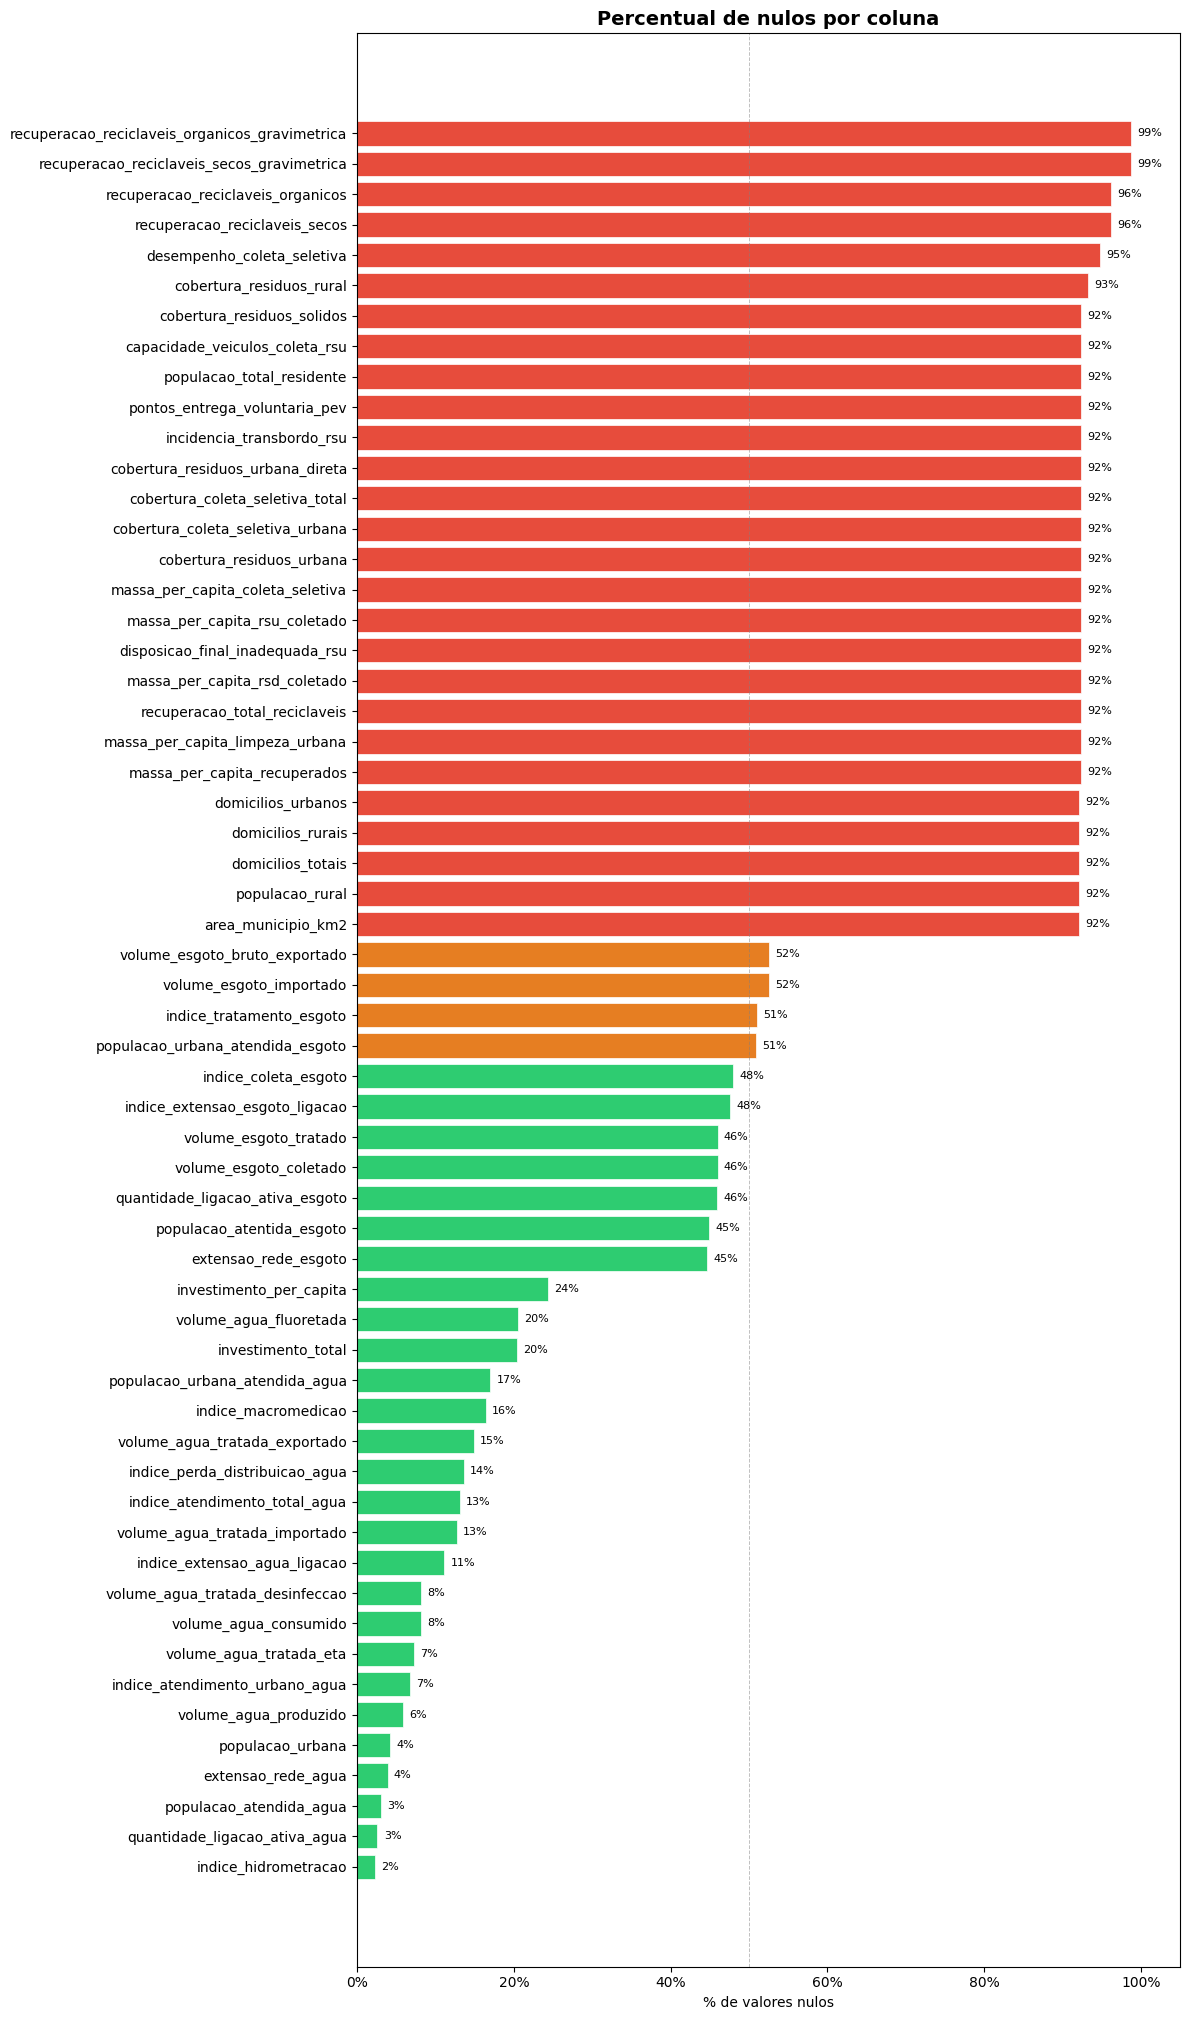

In [68]:
fig, ax = plt.subplots(figsize=(12, max(8, len(colunas_dados) * 0.35)))

cores = ["#2ecc71" if v < 50 else "#e67e22" if v < 80 else "#e74c3c" for v in pct_nulos.values]
bars = ax.barh(pct_nulos.index, pct_nulos.values, color=cores, edgecolor="white", linewidth=0.5)

for bar, pct in zip(bars, pct_nulos.values):
    ax.text(bar.get_width() + 0.8, bar.get_y() + bar.get_height() / 2,
            f"{pct:.0f}%", va="center", fontsize=8)

ax.set_xlabel("% de valores nulos")
ax.set_title("Percentual de nulos por coluna", fontsize=14, fontweight="bold")
ax.invert_yaxis()
ax.set_xlim(0, 105)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.axvline(50, color="gray", linestyle="--", linewidth=0.7, alpha=0.5)
plt.tight_layout()
plt.show()

### 6.2 Preenchimento por ano: quantos municípios têm dado em cada variável

In [69]:
munis_por_ano = df.groupby("ano")["id_municipio"].nunique()

preenchimento_por_ano = (
    df.groupby("ano")[colunas_dados]
    .apply(lambda g: g.notna().sum())
)

pct_preenchimento = preenchimento_por_ano.div(munis_por_ano, axis=0) * 100

print("Municípios por ano:")
print(munis_por_ano.to_string())
print()
print("% de municípios com dado preenchido por ano (últimos 10 anos):")
pct_preenchimento.tail(10).round(0).astype(int)

Municípios por ano:
ano
1995     3
1996    17
1997    20
1998    82
1999    76
2000    73
2001    77
2002    77
2003    79
2004    79
2005    81
2006    84
2007    84
2008    83
2009    79
2010    86
2011    87
2012    88
2013    89
2014    90
2015    89
2016    88
2017    86
2018    87
2019    88
2020    87
2021    90
2022    92
2023    92
2024    91

% de municípios com dado preenchido por ano (últimos 10 anos):


,populacao_total_residente,populacao_urbana,populacao_atendida_agua,populacao_urbana_atendida_agua,indice_atendimento_urbano_agua,indice_atendimento_total_agua,populacao_atentida_esgoto,populacao_urbana_atendida_esgoto,extensao_rede_agua,extensao_rede_esgoto,...,recuperacao_reciclaveis_secos_gravimetrica,recuperacao_reciclaveis_organicos_gravimetrica,recuperacao_total_reciclaveis,recuperacao_reciclaveis_secos,recuperacao_reciclaveis_organicos,indice_perda_distribuicao_agua,indice_macromedicao,indice_hidrometracao,investimento_total,investimento_per_capita
ano,,,,,,,,,,,,,,,,,,,,,
2015,0,100,100,100,100,100,79,79,100,79,...,0,0,0,0,0,100,99,100,100,100
2016,0,100,100,100,100,100,84,84,100,84,...,0,0,0,0,0,100,99,100,100,100
2017,0,100,100,100,100,100,77,77,100,77,...,0,0,0,0,0,100,99,100,100,100
2018,0,100,100,100,100,100,80,80,100,80,...,0,0,0,0,0,100,99,100,100,100
2019,0,100,100,100,100,100,70,70,100,70,...,0,0,0,0,0,100,99,100,100,100
2020,0,100,99,99,99,99,80,80,99,80,...,0,0,0,0,0,99,99,99,100,100
2021,0,100,100,100,100,100,77,76,100,77,...,0,0,0,0,0,100,99,100,100,100
2022,0,0,100,0,0,100,76,0,100,91,...,0,0,0,0,0,100,99,100,100,0
2023,100,100,100,100,96,96,93,73,100,73,...,15,14,97,0,0,99,99,100,0,0


### 6.3 Resumo por grupos temáticos: anos com melhor cobertura

In [70]:
GRUPOS = {
    "População e território": [
        "populacao_total_residente", "populacao_urbana", "populacao_rural",
        "domicilios_totais", "domicilios_urbanos", "domicilios_rurais", "area_municipio_km2",
    ],
    "Água — atendimento": [
        "populacao_atendida_agua", "populacao_urbana_atendida_agua",
        "indice_atendimento_urbano_agua", "indice_atendimento_total_agua",
    ],
    "Água — infraestrutura": [
        "extensao_rede_agua", "quantidade_ligacao_ativa_agua",
        "volume_agua_produzido", "volume_agua_consumido",
    ],
    "Água — qualidade da gestão": [
        "indice_perda_distribuicao_agua", "indice_macromedicao", "indice_hidrometracao",
    ],
    "Esgoto": [
        "populacao_atentida_esgoto", "populacao_urbana_atendida_esgoto",
        "extensao_rede_esgoto", "volume_esgoto_coletado", "volume_esgoto_tratado",
        "indice_coleta_esgoto", "indice_tratamento_esgoto",
    ],
    "Investimento": [
        "investimento_total", "investimento_per_capita",
    ],
    "Resíduos sólidos — cobertura": [
        "cobertura_residuos_solidos", "cobertura_residuos_urbana", "cobertura_residuos_rural",
        "cobertura_coleta_seletiva_total", "cobertura_coleta_seletiva_urbana",
    ],
    "Resíduos sólidos — operacional": [
        "massa_per_capita_rsu_coletado", "massa_per_capita_rsd_coletado",
        "incidencia_transbordo_rsu", "capacidade_veiculos_coleta_rsu",
    ],
    "Resíduos sólidos — qualidade": [
        "disposicao_final_inadequada_rsu", "desempenho_coleta_seletiva",
        "recuperacao_total_reciclaveis",
    ],
}

linhas_resumo = []
for grupo, cols in GRUPOS.items():
    existentes = [c for c in cols if c in df.columns]
    if not existentes:
        continue
    nulos_grupo = df[existentes].isna().sum().sum()
    total_grupo = len(df) * len(existentes)
    pct_nulo = nulos_grupo / total_grupo * 100

    anos_com_dado = df.groupby("ano")[existentes].apply(lambda g: g.notna().any(axis=1).sum())
    anos_ok = anos_com_dado[anos_com_dado > 0].index.tolist()
    faixa = f"{min(anos_ok)}–{max(anos_ok)}" if anos_ok else "-"

    linhas_resumo.append({
        "Grupo": grupo,
        "Variáveis": len(existentes),
        "% nulo": round(pct_nulo, 1),
        "% preenchido": round(100 - pct_nulo, 1),
        "Anos com dados": faixa,
        "Qtd anos": len(anos_ok),
    })

resumo_grupos = pd.DataFrame(linhas_resumo)
resumo_grupos.style.bar(subset=["% preenchido"], color="#", vmin=0, vmax=100)

,Grupo,Variáveis,% nulo,% preenchido,Anos com dados,Qtd anos
0,População e território,7,79.600000,20.400000,1995–2024,29
1,Água — atendimento,4,10.000000,90.000000,1995–2024,30
2,Água — infraestrutura,4,5.100000,94.900000,1995–2024,30
3,Água — qualidade da gestão,3,10.700000,89.300000,1995–2024,30
4,Esgoto,7,47.400000,52.600000,1995–2024,30
5,Investimento,2,22.400000,77.600000,1998–2022,25
6,Resíduos sólidos — cobertura,5,92.500000,7.500000,2023–2024,2
7,Resíduos sólidos — operacional,4,92.400000,7.600000,2023–2024,2
8,Resíduos sólidos — qualidade,3,93.200000,6.800000,2023–2024,2


### 6.5 Quantidade de municípios por ano

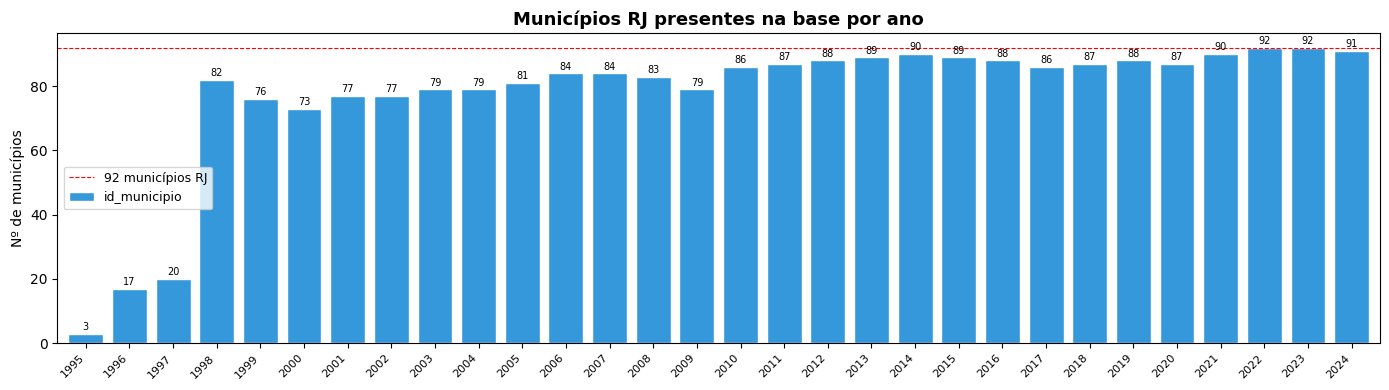

In [71]:
fig, ax = plt.subplots(figsize=(14, 4))
munis_por_ano.plot.bar(ax=ax, color="#3498db", edgecolor="white", width=0.8)
ax.set_title("Municípios RJ presentes na base por ano", fontsize=13, fontweight="bold")
ax.set_ylabel("Nº de municípios")
ax.set_xlabel("")
ax.axhline(92, color="red", linestyle="--", linewidth=0.8, label="92 municípios RJ")
ax.legend(fontsize=9)
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{int(bar.get_height())}",
        ha="center",
        va="bottom",
        fontsize=7,
    )
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.show()

---

## 7. Análise  últimos 10 anos (2015–2024)

Foco nos dados mais recentes para entender:

1. **Evolução dos nulos** por ano — quais variáveis vêm melhorando ou piorando em cobertura
2. **Perfil de completude** dos municípios — quantos campos cada município tem preenchido
3. **Variáveis críticas** — as que mais têm lacunas no período recente
4. **Top municípios com mais dados faltantes** — quem mais precisa de atenção
5. **Correlação entre nulos** — variáveis que tendem a faltar juntas

In [72]:
ANO_INICIO = 2015
ANO_FIM = df["ano"].max()

df10 = df[df["ano"].between(ANO_INICIO, ANO_FIM)].copy()

print(f"Período: {ANO_INICIO}–{ANO_FIM}")
print(f"Linhas: {len(df10):,}  |  Municípios: {df10['id_municipio'].nunique()}")
print(f"Anos: {sorted(df10['ano'].unique())}")

colunas_numericas = [c for c in df10.columns if c not in ("ano", "id_municipio", "nome_municipio", "sigla_uf")]

Período: 2015–2024
Linhas: 890  |  Municípios: 92
Anos: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


### 7.2 Perfil de completude dos municípios — quantos campos cada um preenche

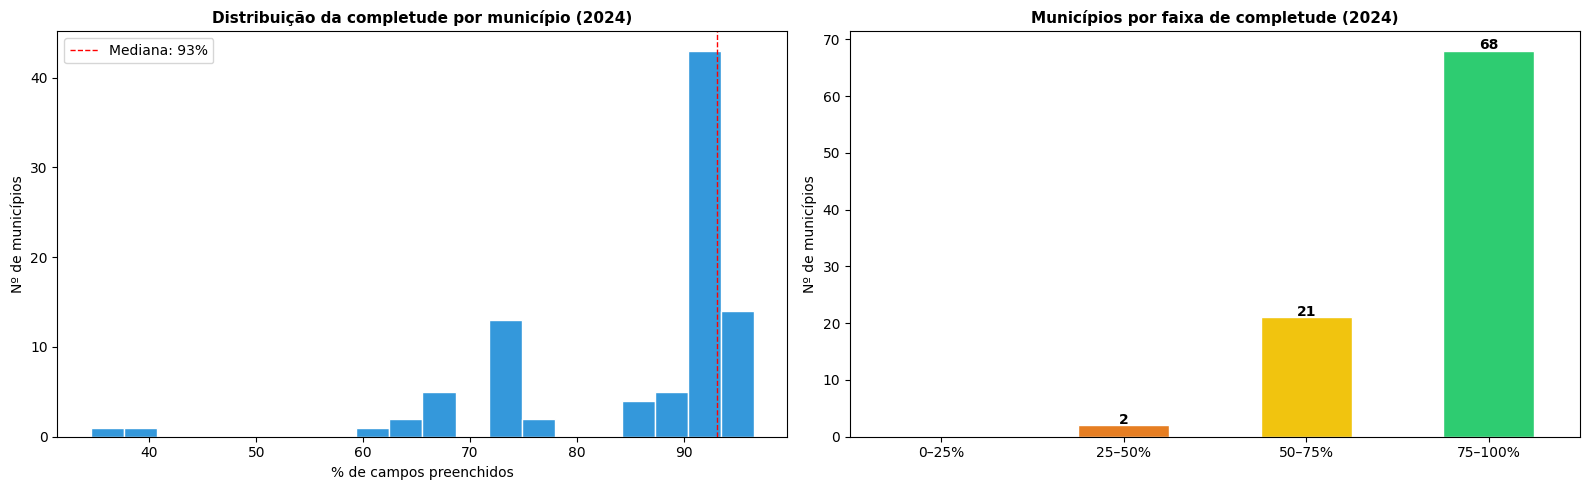


Resumo (2024): 58 variáveis numéricas, 91 municípios
Mediana de preenchimento: 93%
Mínimo: 34% | Máximo: 97%


In [73]:
ultimo_ano = ANO_FIM
df_ultimo = df10[df10["ano"] == ultimo_ano].copy()
total_cols = len(colunas_numericas)

df_ultimo["campos_preenchidos"] = df_ultimo[colunas_numericas].notna().sum(axis=1)
df_ultimo["campos_nulos"] = total_cols - df_ultimo["campos_preenchidos"]
df_ultimo["pct_preenchido"] = (df_ultimo["campos_preenchidos"] / total_cols * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(df_ultimo["pct_preenchido"], bins=20, color="#3498db", edgecolor="white")
axes[0].set_title(f"Distribuição da completude por município ({ultimo_ano})", fontsize=11, fontweight="bold")
axes[0].set_xlabel("% de campos preenchidos")
axes[0].set_ylabel("Nº de municípios")
axes[0].axvline(df_ultimo["pct_preenchido"].median(), color="red", linestyle="--", linewidth=1, label=f"Mediana: {df_ultimo['pct_preenchido'].median():.0f}%")
axes[0].legend()

faixas = pd.cut(df_ultimo["pct_preenchido"], bins=[0, 25, 50, 75, 100], labels=["0–25%", "25–50%", "50–75%", "75–100%"])
contagem = faixas.value_counts().sort_index()
cores_faixa = ["#e74c3c", "#e67e22", "#f1c40f", "#2ecc71"]
contagem.plot.bar(ax=axes[1], color=cores_faixa, edgecolor="white")
axes[1].set_title(f"Municípios por faixa de completude ({ultimo_ano})", fontsize=11, fontweight="bold")
axes[1].set_ylabel("Nº de municípios")
axes[1].set_xlabel("")
for bar in axes[1].patches:
    if bar.get_height() > 0:
        axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                     f"{int(bar.get_height())}", ha="center", fontsize=10, fontweight="bold")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"\nResumo ({ultimo_ano}): {total_cols} variáveis numéricas, {len(df_ultimo)} municípios")
print(f"Mediana de preenchimento: {df_ultimo['pct_preenchido'].median():.0f}%")
print(f"Mínimo: {df_ultimo['pct_preenchido'].min():.0f}% | Máximo: {df_ultimo['pct_preenchido'].max():.0f}%")

### 7.3 Top 15 municípios com mais dados faltantes no último ano

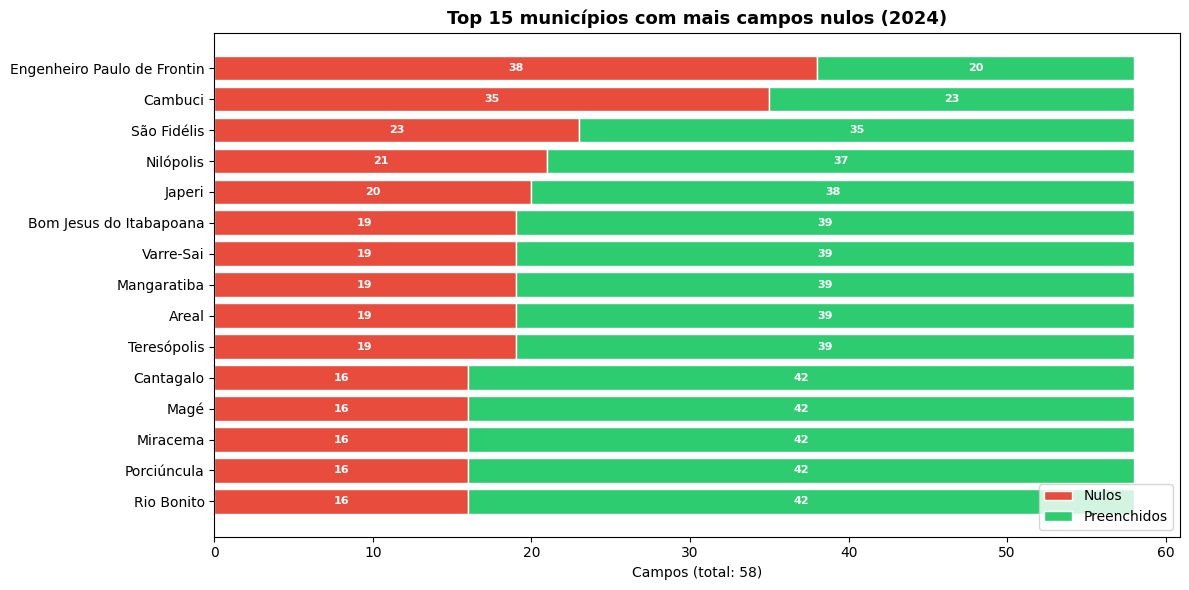

,nome_municipio,campos_preenchidos,campos_nulos,pct_preenchido
0,Engenheiro Paulo de Frontin,20,38,34.5
1,Cambuci,23,35,39.7
2,São Fidélis,35,23,60.3
3,Nilópolis,37,21,63.8
4,Japeri,38,20,65.5
5,Bom Jesus do Itabapoana,39,19,67.2
6,Varre-Sai,39,19,67.2
7,Mangaratiba,39,19,67.2
8,Areal,39,19,67.2
9,Teresópolis,39,19,67.2


In [74]:
top_nulos = (
    df_ultimo[["nome_municipio", "campos_preenchidos", "campos_nulos", "pct_preenchido"]]
    .sort_values("campos_nulos", ascending=False)
    .head(15)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(
    top_nulos["nome_municipio"],
    top_nulos["campos_nulos"],
    color="#e74c3c",
    edgecolor="white",
)
ax.barh(
    top_nulos["nome_municipio"],
    top_nulos["campos_preenchidos"],
    left=top_nulos["campos_nulos"],
    color="#2ecc71",
    edgecolor="white",
    label="Preenchidos",
)

for bar, nulos, preench in zip(bars, top_nulos["campos_nulos"], top_nulos["campos_preenchidos"]):
    ax.text(nulos / 2, bar.get_y() + bar.get_height() / 2,
            f"{nulos}", ha="center", va="center", fontsize=8, color="white", fontweight="bold")
    ax.text(nulos + preench / 2, bar.get_y() + bar.get_height() / 2,
            f"{preench}", ha="center", va="center", fontsize=8, color="white", fontweight="bold")

ax.set_xlabel(f"Campos (total: {total_cols})")
ax.set_title(f"Top 15 municípios com mais campos nulos ({ultimo_ano})", fontsize=13, fontweight="bold")
ax.invert_yaxis()
ax.legend(["Nulos", "Preenchidos"], loc="lower right")
plt.tight_layout()
plt.show()

top_nulos

### 7.4 Quais variáveis mais faltam nos últimos 10 anos — ranking de nulos

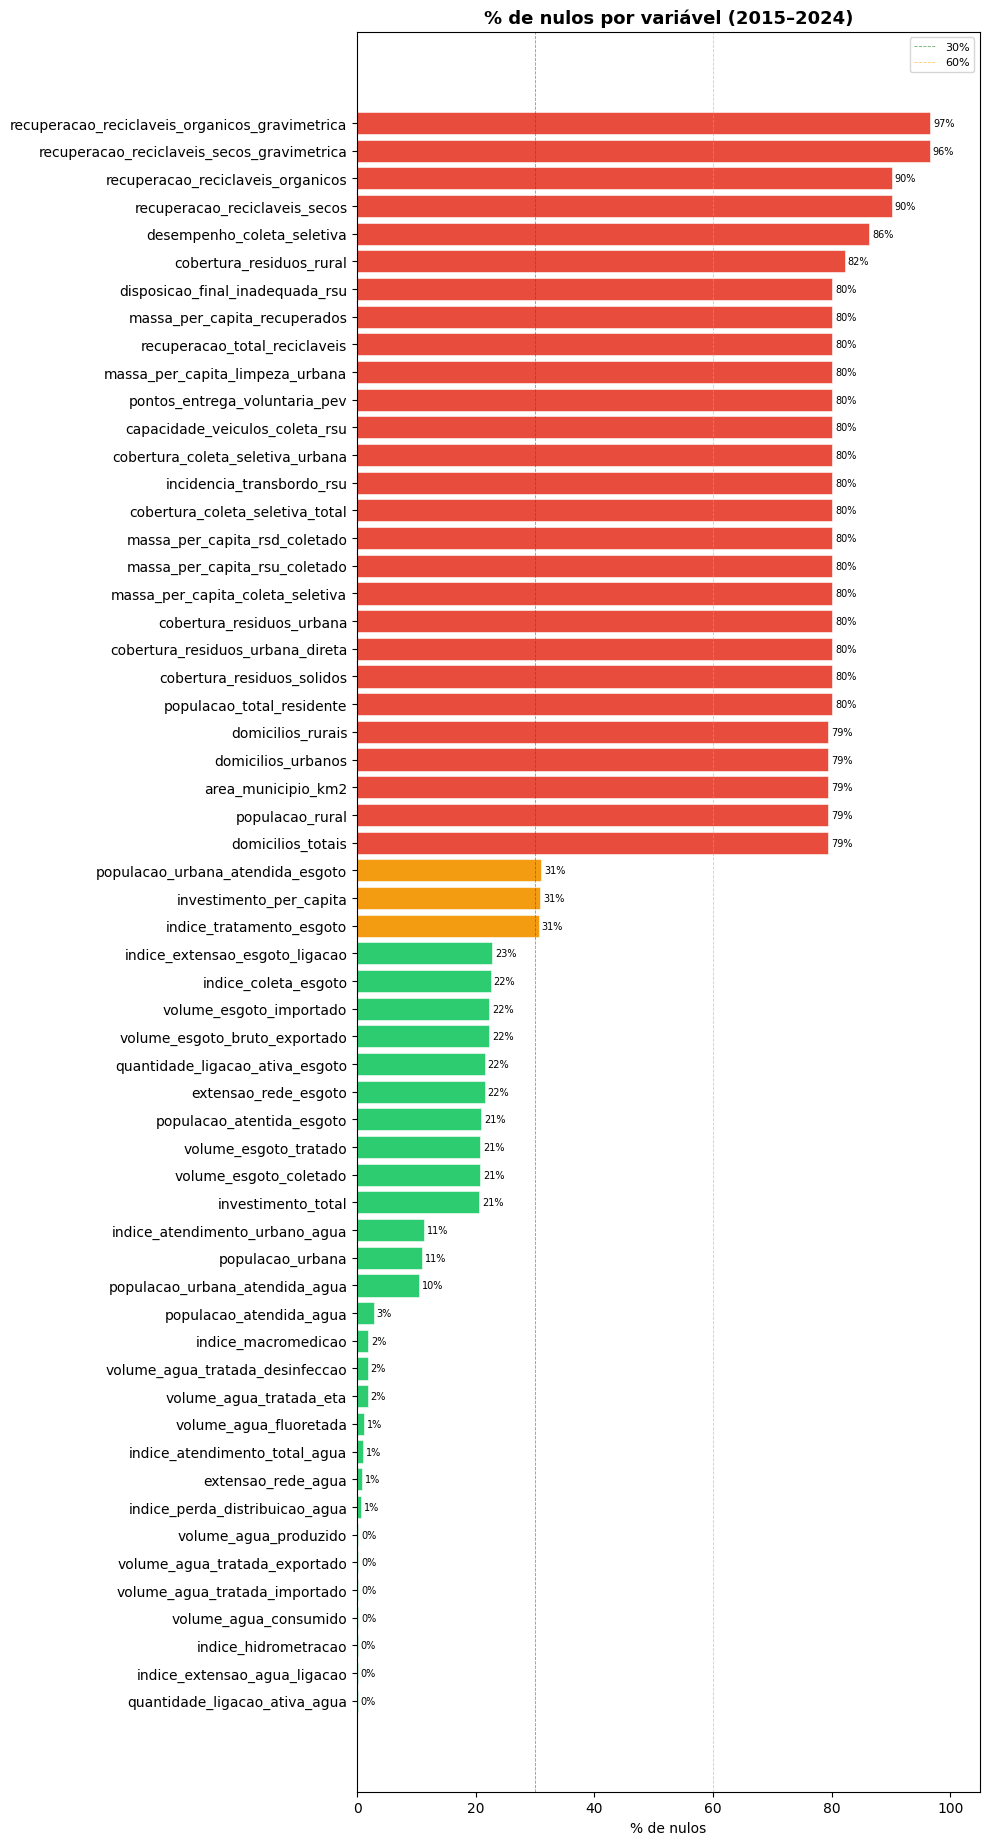

In [75]:
nulos_10 = df10[colunas_numericas].isna().sum().sort_values(ascending=True)
pct_nulos_10 = (nulos_10 / len(df10) * 100).round(1)

fig, ax = plt.subplots(figsize=(10, max(8, len(colunas_numericas) * 0.32)))
cores = ["#2ecc71" if v < 30 else "#f39c12" if v < 60 else "#e74c3c" for v in pct_nulos_10.values]
ax.barh(pct_nulos_10.index, pct_nulos_10.values, color=cores, edgecolor="white", linewidth=0.4)

for i, (val, name) in enumerate(zip(pct_nulos_10.values, pct_nulos_10.index)):
    ax.text(val + 0.5, i, f"{val:.0f}%", va="center", fontsize=7)

ax.set_xlabel("% de nulos")
ax.set_title(f"% de nulos por variável ({ANO_INICIO}–{ANO_FIM})", fontsize=13, fontweight="bold")
ax.set_xlim(0, 105)
ax.axvline(30, color="green", linestyle="--", linewidth=0.6, alpha=0.6, label="30%")
ax.axvline(60, color="orange", linestyle="--", linewidth=0.6, alpha=0.6, label="60%")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### 7.7 Evolução da completude média dos municípios ao longo dos 10 anos

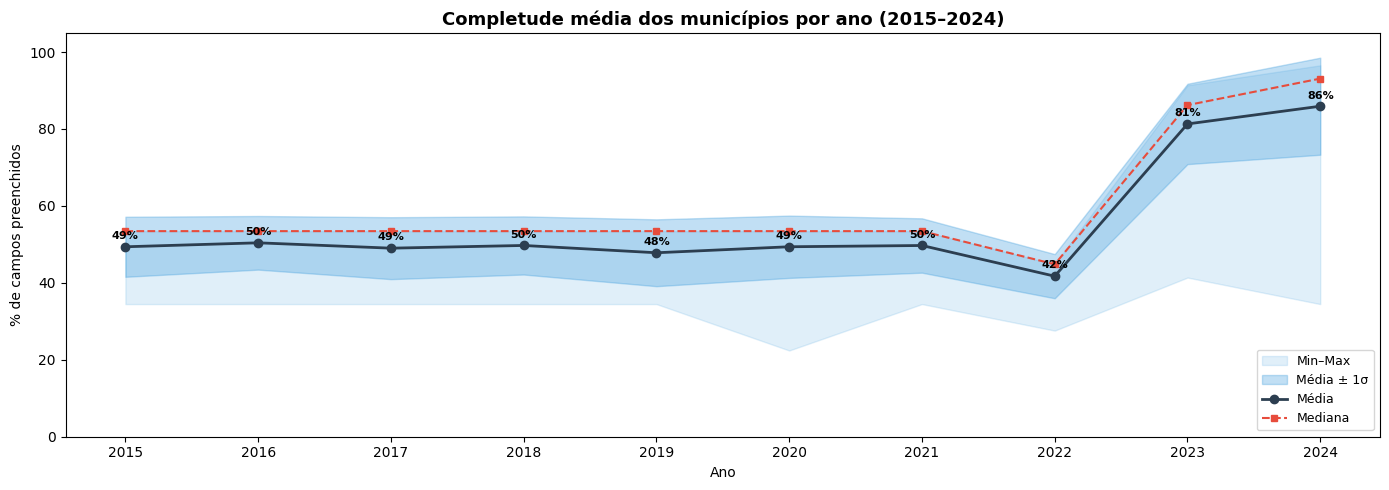

Estatísticas por ano:


,mean,median,min,max,std
ano,,,,,
2015,49.4,53.4,34.5,53.4,7.8
2016,50.4,53.4,34.5,53.4,7.0
2017,49.0,53.4,34.5,53.4,8.1
2018,49.7,53.4,34.5,53.4,7.6
2019,47.8,53.4,34.5,53.4,8.7
2020,49.4,53.4,22.4,53.4,8.1
2021,49.7,53.4,34.5,53.4,7.1
2022,41.7,44.8,27.6,44.8,5.7
2023,81.3,86.2,41.4,91.4,10.4


In [76]:
completude_por_muni_ano = (
    df10.groupby(["ano", "id_municipio"])[colunas_numericas]
    .apply(lambda g: g.notna().sum().sum() / (len(g) * len(colunas_numericas)) * 100)
    .reset_index(name="pct_preenchido")
)

stats_por_ano = completude_por_muni_ano.groupby("ano")["pct_preenchido"].agg(["mean", "median", "min", "max", "std"])

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(stats_por_ano.index, stats_por_ano["min"], stats_por_ano["max"],
                alpha=0.15, color="#3498db", label="Min–Max")
ax.fill_between(stats_por_ano.index, stats_por_ano["mean"] - stats_por_ano["std"],
                stats_por_ano["mean"] + stats_por_ano["std"],
                alpha=0.3, color="#3498db", label="Média ± 1σ")
ax.plot(stats_por_ano.index, stats_por_ano["mean"], "o-", color="#2c3e50", linewidth=2, markersize=6, label="Média")
ax.plot(stats_por_ano.index, stats_por_ano["median"], "s--", color="#e74c3c", linewidth=1.5, markersize=5, label="Mediana")

for x, y in zip(stats_por_ano.index, stats_por_ano["mean"]):
    ax.text(x, y + 2, f"{y:.0f}%", ha="center", fontsize=8, fontweight="bold")

ax.set_title(f"Completude média dos municípios por ano ({ANO_INICIO}–{ANO_FIM})", fontsize=13, fontweight="bold")
ax.set_ylabel("% de campos preenchidos")
ax.set_xlabel("Ano")
ax.set_ylim(0, 105)
ax.legend(fontsize=9, loc="lower right")
ax.set_xticks(stats_por_ano.index)
plt.tight_layout()
plt.show()

print("Estatísticas por ano:")
stats_por_ano.round(1)

---

## 8. Diagnóstico do Saneamento nos Municípios do RJ

Análises cruzando a base consolidada SNIS/SINISA (1995–2024) com os microdados do **Censo IBGE 2022** (domicílios por tipo de esgoto e abastecimento de água, moradores por cor/raça).

Perguntas que vamos responder:

1. Quais são os piores e melhores municípios em saneamento?
2. Existe descompasso entre água, esgoto e resíduos?
3. O RJ está melhorando ou piorando ao longo do tempo?
4. Quem mais perde água? Investimento ajuda?
5. O Censo confirma os dados do SNIS sobre esgoto e água?
6. Há desigualdade racial no acesso a saneamento?
7. Como está a situação de resíduos sólidos?
8. O investimento se traduz em resultado?

In [77]:
IBGE_DIR = PROJECT_ROOT / "data" / "raw" / "ibge_rj"

def carregar_ibge_esgoto() -> pd.DataFrame:
    """Carrega domicílios por tipo de esgotamento sanitário (Censo 2022)."""
    path = IBGE_DIR / "Domicílios particulares permanentes ocupados, por tipo de esgotamento sanitário.csv"
    raw = pd.read_csv(path, sep=";", encoding="utf-8", skiprows=4, quotechar='"')
    raw.columns = [
        "nivel", "cod_ibge", "municipio",
        "total", "rede_geral_fossa_rede", "rede_geral_pluvial",
        "fossa_septica_rede", "fossa_septica_nao_rede",
        "fossa_rudimentar", "vala", "rio_lago", "outra", "sem_banheiro",
    ]
    raw = raw[raw["nivel"] == "MU"].copy()
    raw["cod_ibge"] = raw["cod_ibge"].astype(str).str.strip()
    raw["municipio"] = raw["municipio"].str.replace(r"\s*\(RJ\)\s*", "", regex=True).str.strip()
    for c in raw.columns[3:]:
        raw[c] = pd.to_numeric(raw[c].astype(str).str.replace("-", "0").str.strip(), errors="coerce").fillna(0).astype(int)
    return raw


def carregar_ibge_agua() -> pd.DataFrame:
    """Carrega domicílios por ligação à rede geral de água (Censo 2022)."""
    path = IBGE_DIR / "Domicílios particulares permanentes ocupados, por existência de ligação à rede geral de distribuição de água e principal forma de abastecimento de água.csv"
    raw = pd.read_csv(path, sep=";", encoding="utf-8", skiprows=4, quotechar='"')
    cols = list(raw.columns)
    raw = raw.rename(columns={
        cols[0]: "nivel", cols[1]: "cod_ibge", cols[2]: "municipio",
        cols[3]: "total", cols[4]: "rede_principal",
        cols[5]: "rede_outra_forma", cols[10]: "sem_rede",
    })
    raw = raw[raw["nivel"] == "MU"].copy()
    raw["cod_ibge"] = raw["cod_ibge"].astype(str).str.strip()
    raw["municipio"] = raw["municipio"].str.replace(r"\s*\(RJ\)\s*", "", regex=True).str.strip()
    for c in ["total", "rede_principal", "rede_outra_forma", "sem_rede"]:
        raw[c] = pd.to_numeric(raw[c].astype(str).str.replace("-", "0").str.strip(), errors="coerce").fillna(0).astype(int)
    return raw[["nivel", "cod_ibge", "municipio", "total", "rede_principal", "rede_outra_forma", "sem_rede"]]


ibge_esgoto = carregar_ibge_esgoto()
ibge_agua = carregar_ibge_agua()

print(f"IBGE Esgoto: {len(ibge_esgoto)} municípios")
print(f"IBGE Água:   {len(ibge_agua)} municípios")

ultimo_ano_disponivel = df["ano"].max()
df_atual = df[df["ano"] == ultimo_ano_disponivel].copy()
print(f"\nSNIS/SINISA último ano: {ultimo_ano_disponivel} ({len(df_atual)} municípios)")

IBGE Esgoto: 184 municípios
IBGE Água:   184 municípios

SNIS/SINISA último ano: 2024 (91 municípios)


### 8.1 Ranking dos municípios em saneamento — score composto

Score = média simples de 4 indicadores normalizados (0–100):
- Atendimento total de água (%)
- Coleta de esgoto (%)
- Tratamento de esgoto (%)
- Cobertura de resíduos sólidos (%)

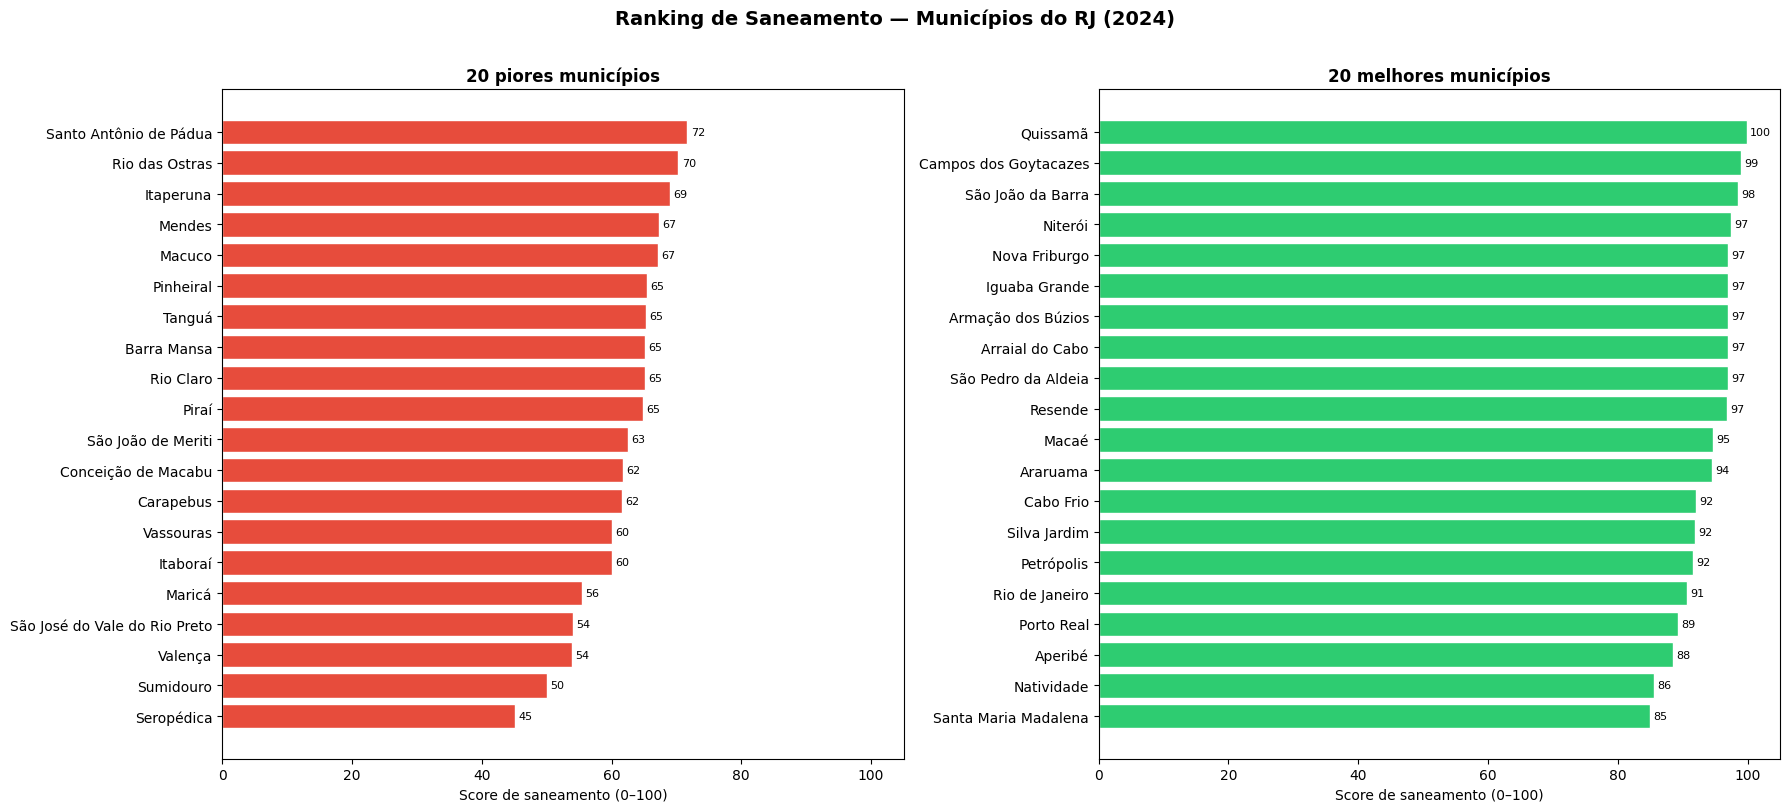


Média estadual: 77.7
Mediana: 75.3
Municípios avaliados: 60 (com dados nos 4 indicadores)


In [78]:
SCORE_COLS = [
    "indice_atendimento_total_agua",
    "indice_coleta_esgoto",
    "indice_tratamento_esgoto",
    "cobertura_residuos_solidos",
]

df_score = df_atual[["nome_municipio", "id_municipio"] + SCORE_COLS].dropna(subset=SCORE_COLS).copy()
df_score["score_saneamento"] = df_score[SCORE_COLS].mean(axis=1).round(1)
df_score = df_score.sort_values("score_saneamento")

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

piores = df_score.head(20)
axes[0].barh(piores["nome_municipio"], piores["score_saneamento"], color="#e74c3c", edgecolor="white")
for i, (v, m) in enumerate(zip(piores["score_saneamento"], piores["nome_municipio"])):
    axes[0].text(v + 0.5, i, f"{v:.0f}", va="center", fontsize=8)
axes[0].set_title("20 piores municípios", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Score de saneamento (0–100)")
axes[0].set_xlim(0, 105)

melhores = df_score.tail(20)
axes[1].barh(melhores["nome_municipio"], melhores["score_saneamento"], color="#2ecc71", edgecolor="white")
for i, (v, m) in enumerate(zip(melhores["score_saneamento"], melhores["nome_municipio"])):
    axes[1].text(v + 0.5, i, f"{v:.0f}", va="center", fontsize=8)
axes[1].set_title("20 melhores municípios", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Score de saneamento (0–100)")
axes[1].set_xlim(0, 105)

fig.suptitle(f"Ranking de Saneamento — Municípios do RJ ({ultimo_ano_disponivel})", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print(f"\nMédia estadual: {df_score['score_saneamento'].mean():.1f}")
print(f"Mediana: {df_score['score_saneamento'].median():.1f}")
print(f"Municípios avaliados: {len(df_score)} (com dados nos 4 indicadores)")

### 8.2 Descompasso entre água, esgoto e resíduos

Municípios com boa cobertura de água podem ter péssimo esgoto (ou vice-versa). Vamos identificar esses descompassos.

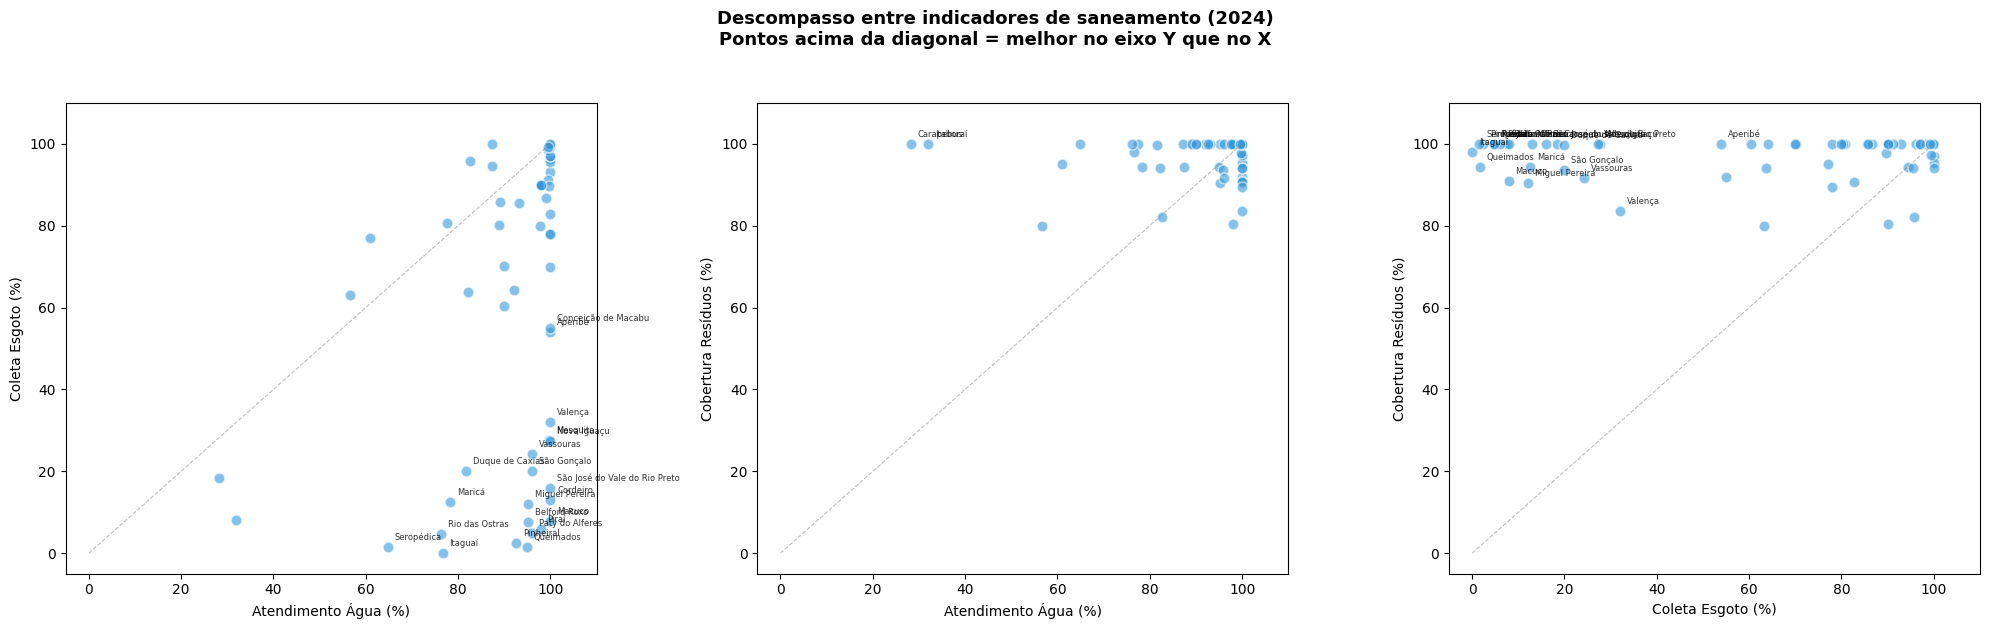

Gap médio (água − esgoto): 30.9 pp
Municípios com água >80% mas esgoto <30%: 14


In [79]:
scatter_cols = {
    "indice_atendimento_total_agua": "Atendimento Água (%)",
    "indice_coleta_esgoto": "Coleta Esgoto (%)",
    "cobertura_residuos_solidos": "Cobertura Resíduos (%)",
}
df_scatter = df_atual[["nome_municipio"] + list(scatter_cols.keys())].dropna().copy()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
pares = [
    ("indice_atendimento_total_agua", "indice_coleta_esgoto"),
    ("indice_atendimento_total_agua", "cobertura_residuos_solidos"),
    ("indice_coleta_esgoto", "cobertura_residuos_solidos"),
]

for ax, (x, y) in zip(axes, pares):
    ax.scatter(df_scatter[x], df_scatter[y], c="#3498db", alpha=0.6, edgecolors="white", s=60)
    ax.plot([0, 100], [0, 100], "--", color="gray", linewidth=0.8, alpha=0.5)
    ax.set_xlabel(scatter_cols[x], fontsize=10)
    ax.set_ylabel(scatter_cols[y], fontsize=10)
    ax.set_xlim(-5, 110)
    ax.set_ylim(-5, 110)

    outliers = df_scatter[((df_scatter[x] - df_scatter[y]).abs() > 40)]
    for _, row in outliers.iterrows():
        ax.annotate(row["nome_municipio"], (row[x], row[y]), fontsize=6, alpha=0.8,
                    textcoords="offset points", xytext=(5, 5))

fig.suptitle(f"Descompasso entre indicadores de saneamento ({ultimo_ano_disponivel})\nPontos acima da diagonal = melhor no eixo Y que no X",
             fontsize=13, fontweight="bold", y=1.04)
plt.tight_layout()
plt.show()

gap = (df_scatter["indice_atendimento_total_agua"] - df_scatter["indice_coleta_esgoto"])
print(f"Gap médio (água − esgoto): {gap.mean():.1f} pp")
print(f"Municípios com água >80% mas esgoto <30%: {((df_scatter['indice_atendimento_total_agua'] > 80) & (df_scatter['indice_coleta_esgoto'] < 30)).sum()}")

### 8.3 Evolução temporal — O RJ está melhorando ou piorando? (2015–2024)

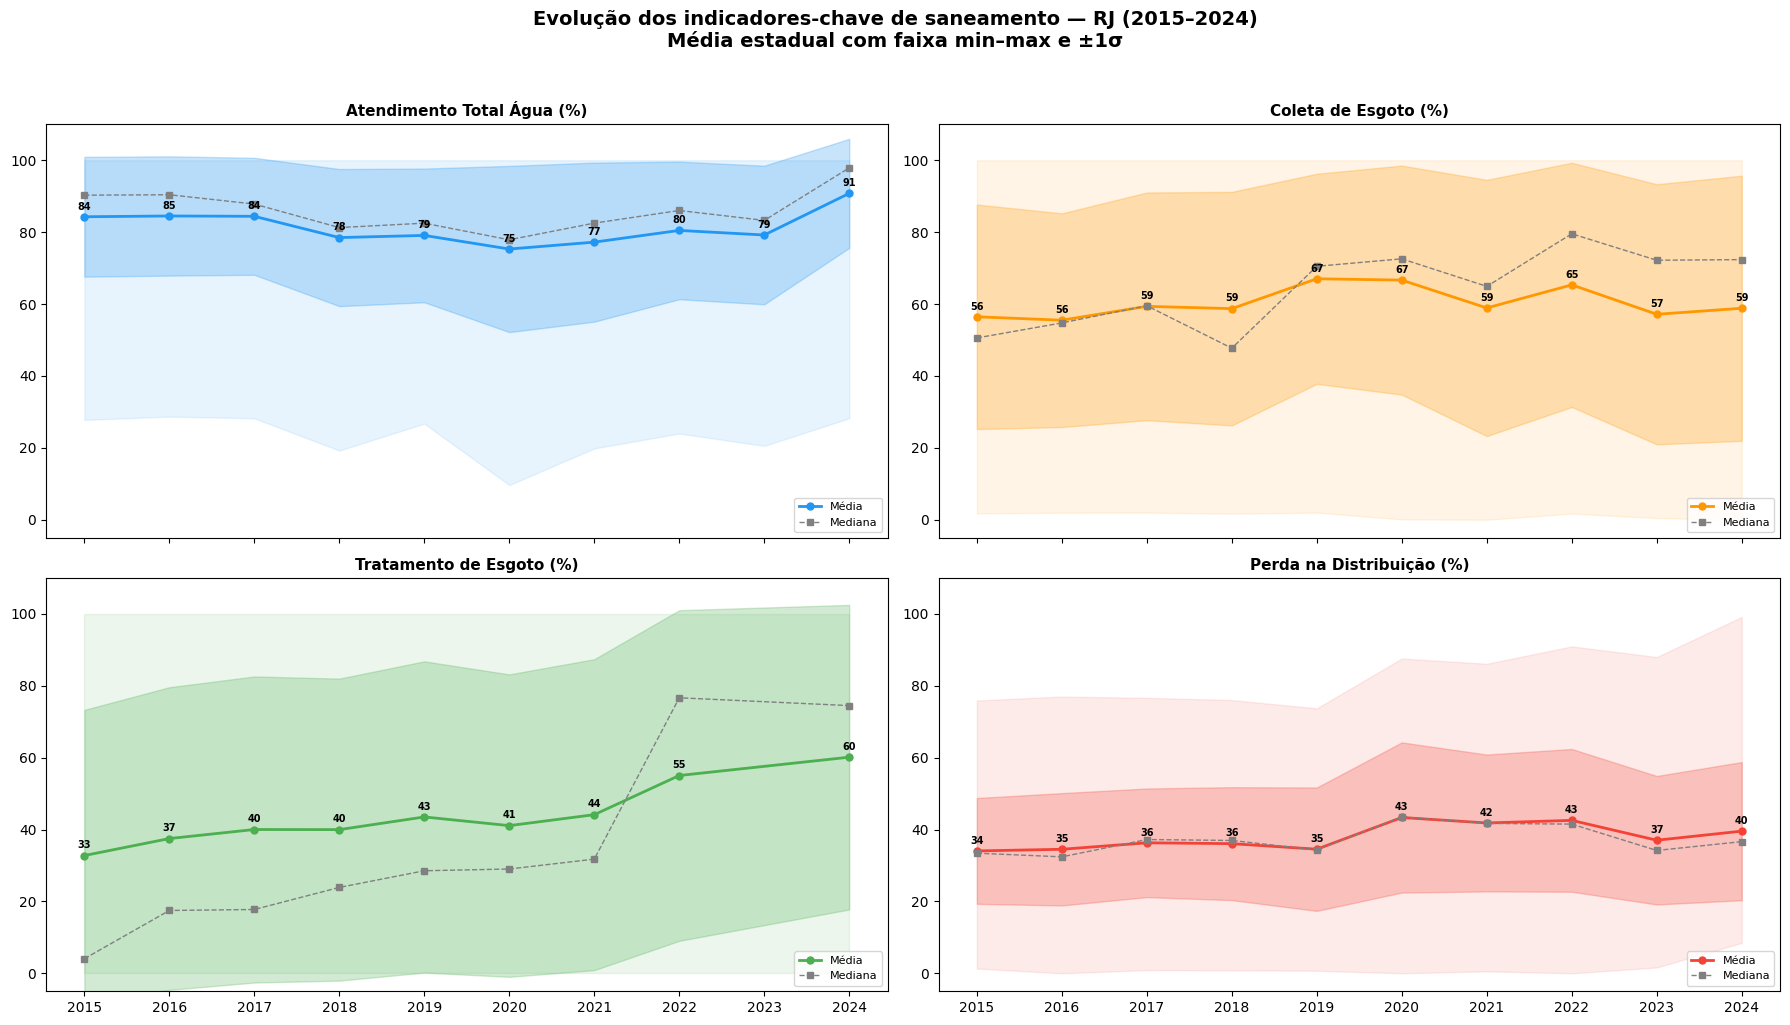

In [80]:
INDICADORES_EVOL = {
    "indice_atendimento_total_agua": ("Atendimento Total Água (%)", "#2196F3"),
    "indice_coleta_esgoto": ("Coleta de Esgoto (%)", "#FF9800"),
    "indice_tratamento_esgoto": ("Tratamento de Esgoto (%)", "#4CAF50"),
    "indice_perda_distribuicao_agua": ("Perda na Distribuição (%)", "#F44336"),
}

df_evol = df[df["ano"].between(2015, ANO_FIM)].copy()

fig, axes = plt.subplots(2, 2, figsize=(18, 10), sharex=True)

for ax, (col, (label, cor)) in zip(axes.flat, INDICADORES_EVOL.items()):
    stats = df_evol.groupby("ano")[col].agg(["mean", "median", "min", "max", "std"]).dropna()
    if stats.empty:
        ax.set_title(f"{label} — sem dados", fontsize=11)
        continue

    ax.fill_between(stats.index, stats["min"], stats["max"], alpha=0.1, color=cor)
    ax.fill_between(stats.index, stats["mean"] - stats["std"],
                    stats["mean"] + stats["std"], alpha=0.25, color=cor)
    ax.plot(stats.index, stats["mean"], "o-", color=cor, linewidth=2, markersize=5, label="Média")
    ax.plot(stats.index, stats["median"], "s--", color="gray", linewidth=1, markersize=4, label="Mediana")

    for x, y in zip(stats.index, stats["mean"]):
        ax.text(x, y + 2, f"{y:.0f}", ha="center", fontsize=7, fontweight="bold")

    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.set_ylim(-5, 110)
    ax.legend(fontsize=8, loc="lower right")
    ax.set_xticks(stats.index)

fig.suptitle(f"Evolução dos indicadores-chave de saneamento — RJ (2015–{ANO_FIM})\nMédia estadual com faixa min–max e ±1σ",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 8.4 Perda de água — Quem mais perde e como evolui?

- Ranking top 15 com maior perda (último ano)
- Série temporal dos 5 piores vs 5 melhores
- Correlação perda × investimento per capita

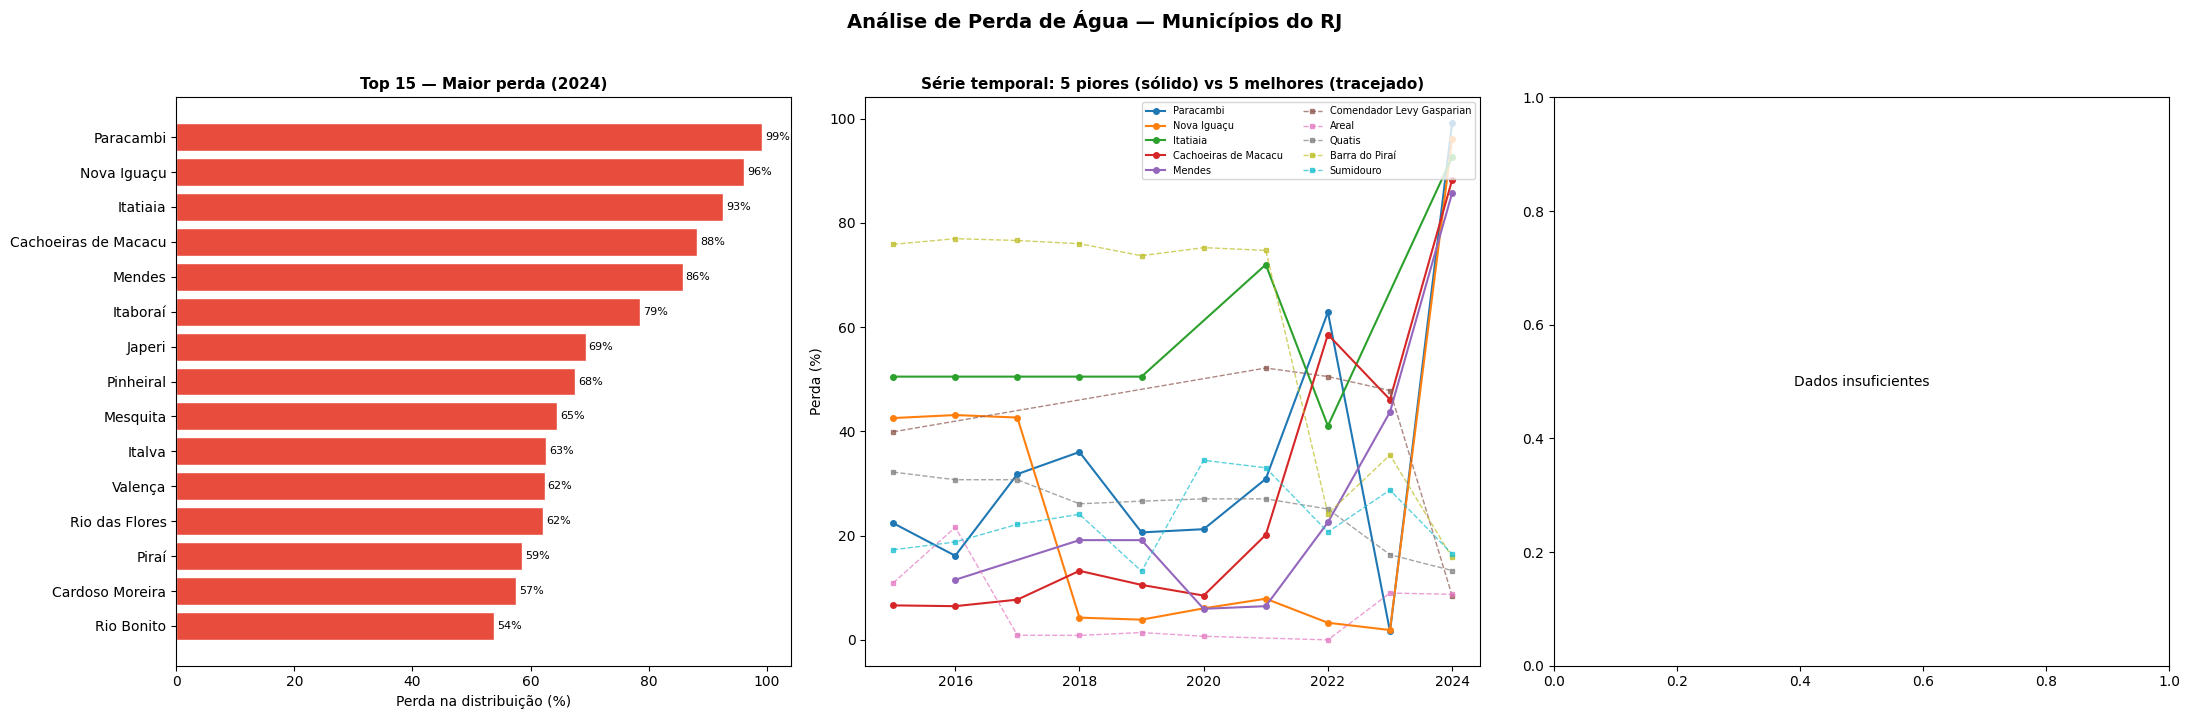

In [81]:
COL_PERDA = "indice_perda_distribuicao_agua"

# --- Top 15 municípios com maior perda ---
df_perda_atual = df_atual[["nome_municipio", "id_municipio", COL_PERDA, "investimento_per_capita"]].dropna(subset=[COL_PERDA]).copy()
df_perda_rank = df_perda_atual.sort_values(COL_PERDA, ascending=False).head(15)

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

colors = ["#e74c3c" if v > 50 else "#f39c12" if v > 30 else "#27ae60" for v in df_perda_rank[COL_PERDA]]
axes[0].barh(df_perda_rank["nome_municipio"][::-1], df_perda_rank[COL_PERDA][::-1],
             color=colors[::-1], edgecolor="white")
for i, v in enumerate(df_perda_rank[COL_PERDA][::-1]):
    axes[0].text(v + 0.5, i, f"{v:.0f}%", va="center", fontsize=8)
axes[0].set_title(f"Top 15 — Maior perda ({ultimo_ano_disponivel})", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Perda na distribuição (%)")

# --- Série temporal 5 piores vs 5 melhores ---
piores_ids = df_perda_rank.head(5)["id_municipio"].tolist()
melhores_perda = df_perda_atual.sort_values(COL_PERDA).head(5)
melhores_ids = melhores_perda["id_municipio"].tolist()

df_ts = df[df["ano"].between(2015, ANO_FIM) & df[COL_PERDA].notna()].copy()

for mid in piores_ids:
    subset = df_ts[df_ts["id_municipio"] == mid]
    nome = subset["nome_municipio"].iloc[0] if len(subset) > 0 else mid
    axes[1].plot(subset["ano"], subset[COL_PERDA], "o-", linewidth=1.5, markersize=4, label=nome)
for mid in melhores_ids:
    subset = df_ts[df_ts["id_municipio"] == mid]
    nome = subset["nome_municipio"].iloc[0] if len(subset) > 0 else mid
    axes[1].plot(subset["ano"], subset[COL_PERDA], "s--", linewidth=1, markersize=3, alpha=0.7, label=nome)

axes[1].set_title("Série temporal: 5 piores (sólido) vs 5 melhores (tracejado)", fontsize=11, fontweight="bold")
axes[1].set_ylabel("Perda (%)")
axes[1].legend(fontsize=7, loc="upper right", ncol=2)

# --- Correlação perda vs investimento per capita ---
df_corr = df_perda_atual.dropna(subset=["investimento_per_capita"])
if len(df_corr) > 5:
    axes[2].scatter(df_corr["investimento_per_capita"], df_corr[COL_PERDA],
                    c="#8e44ad", alpha=0.6, edgecolors="white", s=50)
    z = np.polyfit(df_corr["investimento_per_capita"], df_corr[COL_PERDA], 1)
    x_line = np.linspace(df_corr["investimento_per_capita"].min(), df_corr["investimento_per_capita"].max(), 50)
    axes[2].plot(x_line, np.polyval(z, x_line), "--", color="#e74c3c", linewidth=1.5)
    corr = df_corr["investimento_per_capita"].corr(df_corr[COL_PERDA])
    axes[2].set_title(f"Perda vs Investimento per capita (r={corr:.2f})", fontsize=11, fontweight="bold")
    axes[2].set_xlabel("Investimento per capita (R$)")
    axes[2].set_ylabel("Perda na distribuição (%)")
else:
    axes[2].text(0.5, 0.5, "Dados insuficientes", ha="center", va="center", transform=axes[2].transAxes)

fig.suptitle(f"Análise de Perda de Água — Municípios do RJ", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---

## 9. Modelagem Estatística do Saneamento no RJ

Aplicamos três técnicas de aprendizado de máquina para extrair insights dos dados:

1. **Regressão Linear Múltipla** — quais fatores mais explicam a coleta de esgoto?
2. **Regressão Logística** — o que distingue municípios com saneamento adequado vs inadequado?
3. **Clusterização (K-Means)** — existem grupos naturais de municípios com perfis semelhantes?

Todas as análises usam dados do último ano disponível com `StandardScaler` para padronização.

### 9.1 Regressão Linear Múltipla

**Pergunta:** Quais fatores mais explicam o índice de coleta de esgoto dos municípios?

- **y:** `indice_coleta_esgoto`
- **X:** investimento per capita, perda de água, extensão de rede de esgoto, população urbana, hidrometração

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

TARGET_REG = "indice_coleta_esgoto"
FEATURES_REG = [
    "investimento_per_capita",
    "indice_perda_distribuicao_agua",
    "extensao_rede_esgoto",
    "populacao_urbana",
    "indice_hidrometracao",
]

FEATURE_LABELS = {
    "investimento_per_capita": "Investimento\nper capita",
    "indice_perda_distribuicao_agua": "Perda de\nágua (%)",
    "extensao_rede_esgoto": "Extensão rede\nesgoto (km)",
    "populacao_urbana": "População\nurbana",
    "indice_hidrometracao": "Hidrometração\n(%)",
}

df_reg = df_atual[FEATURES_REG + [TARGET_REG, "nome_municipio"]].dropna().copy()
print(f"Municípios com dados completos para regressão: {len(df_reg)}")

X = df_reg[FEATURES_REG].values
y = df_reg[TARGET_REG].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- statsmodels para p-values e R² ---
X_sm = sm.add_constant(X_scaled)
modelo_ols = sm.OLS(y, X_sm).fit()
print(modelo_ols.summary())

# --- sklearn para gráficos ---
lr = LinearRegression()
lr.fit(X_scaled, y)
y_pred = lr.predict(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Coeficientes
coefs = pd.Series(lr.coef_, index=[FEATURE_LABELS.get(f, f) for f in FEATURES_REG])
colors = ["#2ecc71" if c > 0 else "#e74c3c" for c in coefs]
coefs.plot.barh(ax=axes[0], color=colors, edgecolor="white")
axes[0].set_title(f"Coeficientes padronizados (R²={lr.score(X_scaled, y):.3f})", fontsize=11, fontweight="bold")
axes[0].axvline(0, color="gray", linewidth=0.8)
axes[0].set_xlabel("Efeito no índice de coleta de esgoto")

# Predito vs Real
axes[1].scatter(y, y_pred, c="#3498db", alpha=0.6, edgecolors="white", s=50)
lim = [min(y.min(), y_pred.min()) - 5, max(y.max(), y_pred.max()) + 5]
axes[1].plot(lim, lim, "--", color="gray", linewidth=1)
axes[1].set_xlabel("Valor real (%)")
axes[1].set_ylabel("Valor predito (%)")
axes[1].set_title("Predito vs Real", fontsize=11, fontweight="bold")
axes[1].set_xlim(lim)
axes[1].set_ylim(lim)

# Resíduos
residuos = y - y_pred
axes[2].scatter(y_pred, residuos, c="#9b59b6", alpha=0.6, edgecolors="white", s=50)
axes[2].axhline(0, color="gray", linewidth=1)
axes[2].set_xlabel("Valor predito (%)")
axes[2].set_ylabel("Resíduo")
axes[2].set_title("Análise de resíduos", fontsize=11, fontweight="bold")

fig.suptitle(f"Regressão Linear Múltipla — Índice de Coleta de Esgoto ({ultimo_ano_disponivel})",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(f"\nInterpretação: a cada 1σ de aumento em cada feature, o efeito na coleta de esgoto (pp):")
for feat, coef in zip(FEATURES_REG, lr.coef_):
    sinal = "+" if coef > 0 else ""
    print(f"  {feat:40s} → {sinal}{coef:.2f} pp")

### 9.2 Regressão Logística

**Pergunta:** O que distingue municípios com saneamento adequado vs inadequado?

- Score composto = média(atendimento água, coleta esgoto, tratamento esgoto, cobertura resíduos)
- **Adequado** (1) se score > 60, senão **Inadequado** (0)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, accuracy_score

SCORE_COLS_LOG = [
    "indice_atendimento_total_agua",
    "indice_coleta_esgoto",
    "indice_tratamento_esgoto",
    "cobertura_residuos_solidos",
]

FEATURES_LOG = [
    "investimento_per_capita",
    "populacao_urbana",
    "indice_perda_distribuicao_agua",
    "extensao_rede_agua",
    "extensao_rede_esgoto",
    "massa_per_capita_rsu_coletado",
]

FEAT_LABELS_LOG = {
    "investimento_per_capita": "Investimento per capita",
    "populacao_urbana": "Pop. urbana",
    "indice_perda_distribuicao_agua": "Perda de água",
    "extensao_rede_agua": "Ext. rede água",
    "extensao_rede_esgoto": "Ext. rede esgoto",
    "massa_per_capita_rsu_coletado": "Massa RSU per capita",
}

df_log = df_atual[FEATURES_LOG + SCORE_COLS_LOG + ["nome_municipio"]].dropna().copy()
df_log["score"] = df_log[SCORE_COLS_LOG].mean(axis=1)
df_log["adequado"] = (df_log["score"] > 60).astype(int)

print(f"Municípios: {len(df_log)} | Adequados: {df_log['adequado'].sum()} | Inadequados: {(1 - df_log['adequado']).sum()}")

X_log = df_log[FEATURES_LOG].values
y_log = df_log["adequado"].values

scaler_log = StandardScaler()
X_log_scaled = scaler_log.fit_transform(X_log)

clf = LogisticRegression(random_state=42, max_iter=1000)
clf.fit(X_log_scaled, y_log)
y_pred_log = clf.predict(X_log_scaled)
y_proba = clf.predict_proba(X_log_scaled)[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Odds ratios
odds = np.exp(clf.coef_[0])
odds_df = pd.Series(odds, index=[FEAT_LABELS_LOG.get(f, f) for f in FEATURES_LOG]).sort_values()
colors_or = ["#e74c3c" if v < 1 else "#2ecc71" for v in odds_df]
odds_df.plot.barh(ax=axes[0], color=colors_or, edgecolor="white")
axes[0].axvline(1, color="gray", linewidth=1, linestyle="--")
axes[0].set_title("Odds Ratios (>1 = favorece adequado)", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Odds Ratio")

# Matriz de confusão
cm = confusion_matrix(y_log, y_pred_log)
ConfusionMatrixDisplay(cm, display_labels=["Inadequado", "Adequado"]).plot(ax=axes[1], cmap="Blues")
acc = accuracy_score(y_log, y_pred_log)
axes[1].set_title(f"Matriz de Confusão (acurácia={acc:.1%})", fontsize=11, fontweight="bold")

# Curva ROC
fpr, tpr, _ = roc_curve(y_log, y_proba)
roc_auc = auc(fpr, tpr)
axes[2].plot(fpr, tpr, color="#e74c3c", linewidth=2, label=f"AUC = {roc_auc:.3f}")
axes[2].plot([0, 1], [0, 1], "--", color="gray", linewidth=1)
axes[2].set_xlabel("Taxa de Falsos Positivos")
axes[2].set_ylabel("Taxa de Verdadeiros Positivos")
axes[2].set_title("Curva ROC", fontsize=11, fontweight="bold")
axes[2].legend(fontsize=10)
axes[2].set_xlim(-0.02, 1.02)
axes[2].set_ylim(-0.02, 1.02)

fig.suptitle(f"Regressão Logística — Saneamento Adequado vs Inadequado ({ultimo_ano_disponivel})",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("\nOdds Ratios (por 1σ de aumento na feature):")
for feat, od in zip(FEATURES_LOG, odds):
    print(f"  {feat:40s} → OR = {od:.3f} {'↑ favorece' if od > 1 else '↓ desfavorece'}")

### 9.3 Clusterização (K-Means)

**Pergunta:** Existem grupos naturais de municípios com perfis semelhantes de saneamento?

Features: atendimento água, coleta esgoto, tratamento esgoto, perda de água, cobertura resíduos, investimento per capita.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

FEATURES_CLUSTER = [
    "indice_atendimento_total_agua",
    "indice_coleta_esgoto",
    "indice_tratamento_esgoto",
    "indice_perda_distribuicao_agua",
    "cobertura_residuos_solidos",
    "investimento_per_capita",
]

FEAT_LABELS_CL = {
    "indice_atendimento_total_agua": "Água (%)",
    "indice_coleta_esgoto": "Esgoto (%)",
    "indice_tratamento_esgoto": "Trat. esgoto (%)",
    "indice_perda_distribuicao_agua": "Perda água (%)",
    "cobertura_residuos_solidos": "Resíduos (%)",
    "investimento_per_capita": "Invest. per capita",
}

df_cl = df_atual[FEATURES_CLUSTER + ["nome_municipio"]].dropna().copy()
print(f"Municípios com dados completos para clusterização: {len(df_cl)}")

X_cl = df_cl[FEATURES_CLUSTER].values
scaler_cl = StandardScaler()
X_cl_scaled = scaler_cl.fit_transform(X_cl)

# --- Método do cotovelo + Silhouette ---
K_range = range(2, 10)
inertias = []
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cl_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cl_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_range), inertias, "o-", color="#3498db", linewidth=2, markersize=6)
axes[0].set_xlabel("Número de clusters (k)")
axes[0].set_ylabel("Inércia")
axes[0].set_title("Método do Cotovelo", fontsize=11, fontweight="bold")

axes[1].plot(list(K_range), silhouettes, "s-", color="#e74c3c", linewidth=2, markersize=6)
axes[1].set_xlabel("Número de clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score por k", fontsize=11, fontweight="bold")

best_k = list(K_range)[np.argmax(silhouettes)]
axes[1].axvline(best_k, color="gray", linestyle="--", linewidth=1)
axes[1].annotate(f"melhor k={best_k}", xy=(best_k, max(silhouettes)),
                 xytext=(best_k + 0.5, max(silhouettes) - 0.03), fontsize=10,
                 arrowprops=dict(arrowstyle="->"))

plt.tight_layout()
plt.show()

print(f"\nMelhor k pelo Silhouette Score: {best_k} (score = {max(silhouettes):.3f})")

In [ ]:
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_cl["cluster"] = km_final.fit_predict(X_cl_scaled)

# --- PCA 2D ---
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_cl_scaled)
df_cl["pca1"] = coords[:, 0]
df_cl["pca2"] = coords[:, 1]

cluster_colors = ["#e74c3c", "#2ecc71", "#3498db", "#f39c12", "#9b59b6", "#1abc9c", "#e67e22", "#34495e"]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for cl in sorted(df_cl["cluster"].unique()):
    subset = df_cl[df_cl["cluster"] == cl]
    axes[0].scatter(subset["pca1"], subset["pca2"], c=cluster_colors[cl % len(cluster_colors)],
                    label=f"Cluster {cl} (n={len(subset)})", s=70, alpha=0.7, edgecolors="white")
    for _, row in subset.iterrows():
        axes[0].annotate(row["nome_municipio"], (row["pca1"], row["pca2"]),
                         fontsize=5.5, alpha=0.7, textcoords="offset points", xytext=(4, 4))

axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variância)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variância)")
axes[0].set_title(f"Clusters de municípios (PCA 2D, k={best_k})", fontsize=12, fontweight="bold")
axes[0].legend(fontsize=9)

# --- Perfil médio por cluster (radar simplificado como barras agrupadas) ---
perfil = df_cl.groupby("cluster")[FEATURES_CLUSTER].mean()
perfil_renamed = perfil.rename(columns=FEAT_LABELS_CL)
perfil_renamed.T.plot.bar(ax=axes[1], color=cluster_colors[:best_k], edgecolor="white", width=0.8)
axes[1].set_title("Perfil médio por cluster", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Valor médio")
axes[1].legend(title="Cluster", fontsize=9)
axes[1].tick_params(axis="x", rotation=30)

fig.suptitle(f"Clusterização K-Means — Perfis de Saneamento ({ultimo_ano_disponivel})",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# --- Tabela de perfis ---
print("\n=== Perfil médio por cluster ===\n")
perfil_display = perfil.round(1)
perfil_display.columns = [FEAT_LABELS_CL.get(c, c) for c in perfil_display.columns]
perfil_display["Municípios"] = df_cl.groupby("cluster")["nome_municipio"].apply(lambda x: len(x))
print(perfil_display.to_string())

# --- Classificação dos clusters ---
score_cluster = perfil[["indice_atendimento_total_agua", "indice_coleta_esgoto",
                         "indice_tratamento_esgoto", "cobertura_residuos_solidos"]].mean(axis=1)
nomes_cluster = {}
for cl in score_cluster.index:
    s = score_cluster[cl]
    if s >= 70:
        nomes_cluster[cl] = "Saneamento bom"
    elif s >= 40:
        nomes_cluster[cl] = "Em transição"
    else:
        nomes_cluster[cl] = "Saneamento precário"

print("\n=== Classificação dos clusters ===")
for cl, nome in sorted(nomes_cluster.items()):
    munis = df_cl[df_cl["cluster"] == cl]["nome_municipio"].tolist()
    print(f"\nCluster {cl} — {nome} (score médio: {score_cluster[cl]:.1f})")
    print(f"  Municípios ({len(munis)}): {', '.join(sorted(munis)[:10])}", end="")
    if len(munis) > 10:
        print(f" ... e mais {len(munis) - 10}")
    else:
        print()